# NSL-KDD Preprocessing Pipeline
A clean, modular pipeline for loading, labeling, and preprocessing the NSL-KDD intrusion detection dataset.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn import preprocessing
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
import joblib
from sklearn.preprocessing import MinMaxScaler
plt.style.use("seaborn-v0_8-whitegrid")


## 1. Configuration

In [2]:
TRAIN_PATH = "./KDDTrain+_20Percent.txt"
TEST_PATH  = "./KDDTest+.txt"

COLUMNS = [
    "duration", "protocol_type", "service", "flag", "src_bytes", "dst_bytes",
    "land", "wrong_fragment", "urgent", "hot", "num_failed_logins", "logged_in",
    "num_compromised", "root_shell", "su_attempted", "num_root", "num_file_creations",
    "num_shells", "num_access_files", "num_outbound_cmds", "is_host_login",
    "is_guest_login", "count", "srv_count", "serror_rate", "srv_serror_rate",
    "rerror_rate", "srv_rerror_rate", "same_srv_rate", "diff_srv_rate",
    "srv_diff_host_rate", "dst_host_count", "dst_host_srv_count",
    "dst_host_same_srv_rate", "dst_host_diff_srv_rate", "dst_host_same_src_port_rate",
    "dst_host_srv_diff_host_rate", "dst_host_serror_rate", "dst_host_srv_serror_rate",
    "dst_host_rerror_rate", "dst_host_srv_rerror_rate", "attack_class", "num_learners",
]

# Columns that are always zero / redundant in NSL-KDD
DROP_COLS = ["num_outbound_cmds", "num_learners"]

CAT_COLS = ["protocol_type", "service", "flag"]

# Unified attack-group mapping (single source of truth)
ATTACK_GROUP = {
    # Probe
    "ipsweep": "Probe", "satan": "Probe", "nmap": "Probe", "portsweep": "Probe",
    "saint": "Probe", "mscan": "Probe",
    # DoS
    "teardrop": "DoS", "pod": "DoS", "land": "DoS", "back": "DoS",
    "neptune": "DoS", "smurf": "DoS", "mailbomb": "DoS", "udpstorm": "DoS",
    "apache2": "DoS", "processtable": "DoS",
    # U2R
    "perl": "U2R", "loadmodule": "U2R", "rootkit": "U2R", "buffer_overflow": "U2R",
    "xterm": "U2R", "ps": "U2R", "sqlattack": "U2R", "httptunnel": "U2R",
    # R2L
    "ftp_write": "R2L", "phf": "R2L", "guess_passwd": "R2L", "warezmaster": "R2L",
    "warezclient": "R2L", "imap": "R2L", "spy": "R2L", "multihop": "R2L",
    "named": "R2L", "snmpguess": "R2L", "worm": "R2L", "snmpgetattack": "R2L",
    "xsnoop": "R2L", "xlock": "R2L", "sendmail": "R2L",
    # Normal
    "normal": "Normal",
}


## 2. Data Loading

In [3]:
def load_nslkdd(train_path: str = TRAIN_PATH, test_path: str = TEST_PATH):
    """Load NSL-KDD train/test CSVs, drop redundant columns, and return raw DataFrames."""
    train_df = pd.read_csv(train_path, names=COLUMNS)
    test_df  = pd.read_csv(test_path,  names=COLUMNS)

    train_df.drop(columns=DROP_COLS, inplace=True)
    test_df.drop(columns=DROP_COLS,  inplace=True)
    assert not train_df.isnull().any().any(), "NaNs found in X_train_p!"
    assert not test_df.isnull().any().any(),  "NaNs found in X_test_p!"

    print(f"Train shape : {train_df.shape}")
    print(f"Test  shape : {test_df.shape}")
    return train_df, test_df


## 3. Label Engineering

In [4]:
def label_data(train_df: pd.DataFrame, test_df: pd.DataFrame):
    """
    Map raw attack labels to 5 groups, then encode them numerically.
    Returns X_train, y_train, X_test, y_test, and the fitted LabelEncoder.
    """
    for df, name in [(train_df, "train"), (test_df, "test")]:
        unknown = set(df["attack_class"].unique()) - set(ATTACK_GROUP.keys())
        if unknown:
            print(f"[{name}] WARNING: unmapped attack types: {unknown}")

    train_df = train_df.copy()
    test_df  = test_df.copy()

    train_df["attack_group"] = train_df["attack_class"].map(ATTACK_GROUP)
    test_df["attack_group"]  = test_df["attack_class"].map(ATTACK_GROUP)

    # Encode labels
    le = preprocessing.LabelEncoder()
    y_train = le.fit_transform(train_df["attack_group"])
    y_test  = le.transform(test_df["attack_group"])

    print("Label mapping:", dict(zip(le.classes_, le.transform(le.classes_))))

    # Drop label columns to get feature matrices
    X_train = train_df.drop(columns=["attack_class", "attack_group"])
    X_test  = test_df.drop(columns=["attack_class",  "attack_group"])

    # Wrap labels as Series for convenience
    y_train = pd.Series(y_train, name="attack", index=X_train.index)
    y_test  = pd.Series(y_test,  name="attack", index=X_test.index)

    return X_train, y_train, X_test, y_test, le


## 4. Preprocessing Pipeline

In [5]:
def build_preprocessor(X_train: pd.DataFrame):
    """Build a ColumnTransformer that scales numerics and one-hot encodes categoricals."""
    num_cols = [c for c in X_train.columns if c not in CAT_COLS]

    preprocessor = ColumnTransformer(
        transformers=[
            ("num",MinMaxScaler(), num_cols),
            ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), CAT_COLS),
        ],
        remainder="drop",
        verbose_feature_names_out=False,  # cleaner column names (no "num__" prefix)
    )
    return preprocessor


def run_pipeline(train_path: str = TRAIN_PATH, test_path: str = TEST_PATH):
    """End-to-end: load → label → preprocess. Returns analysis-ready DataFrames."""
    train_df, test_df = load_nslkdd(train_path, test_path)
    X_train, y_train, X_test, y_test, le = label_data(train_df, test_df)

    preprocessor = build_preprocessor(X_train)

    X_train_p = pd.DataFrame(
        preprocessor.fit_transform(X_train),
        columns=preprocessor.get_feature_names_out(),
        index=X_train.index,
    )
    X_test_p = pd.DataFrame(
        preprocessor.transform(X_test),
        columns=preprocessor.get_feature_names_out(),
        index=X_test.index,
    )

    # Sanity checks

    print(f"X_train_p: {X_train_p.shape}  |  X_test_p: {X_test_p.shape}")
    joblib.dump(X_train_p, "X_train_p1.pkl")
    joblib.dump(y_train, "y_train1.pkl")
    joblib.dump(X_test_p, "X_test_p1.pkl")
    joblib.dump(y_test, "y_test1.pkl")
    return X_train_p, y_train, X_test_p, y_test, preprocessor, le


X_train_p, y_train, X_test_p, y_test, preprocessor, le = run_pipeline()


Train shape : (25192, 41)
Test  shape : (22544, 41)
Label mapping: {'DoS': np.int64(0), 'Normal': np.int64(1), 'Probe': np.int64(2), 'R2L': np.int64(3), 'U2R': np.int64(4)}
X_train_p: (25192, 117)  |  X_test_p: (22544, 117)


## 5. EDA

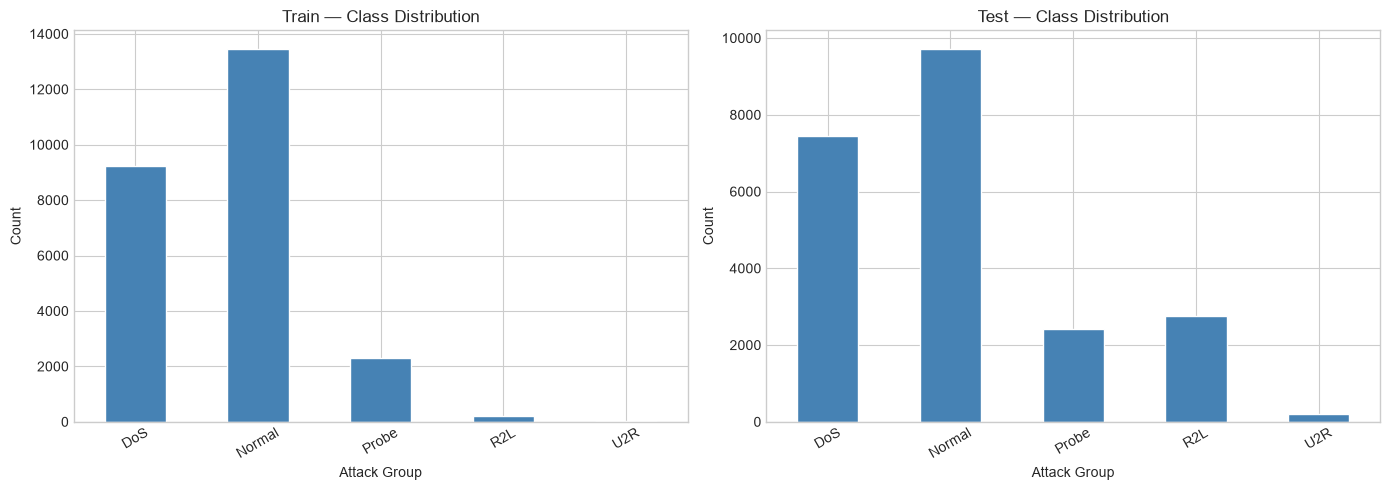

Train class counts:
attack
Normal    13449
DoS        9234
Probe      2289
R2L         209
U2R          11
Name: count, dtype: int64
Test class counts:
attack
Normal    9711
DoS       7458
R2L       2754
Probe     2421
U2R        200
Name: count, dtype: int64


In [6]:
# --- 5a. Class distribution ---
label_names = dict(enumerate(le.classes_))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, (y, title) in zip(axes, [(y_train, "Train"), (y_test, "Test")]):
    counts = y.value_counts().sort_index()
    counts.index = [label_names[i] for i in counts.index]
    counts.plot(kind="bar", ax=ax, color="steelblue", edgecolor="white")
    ax.set_title(f"{title} — Class Distribution")
    ax.set_xlabel("Attack Group")
    ax.set_ylabel("Count")
    ax.tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()

print("Train class counts:")
print(y_train.map(label_names).value_counts())
print("Test class counts:")
print(y_test.map(label_names).value_counts())


Top 30 features by Information Gain (Mutual Information):
['src_bytes', 'diff_srv_rate', 'same_srv_rate', 'dst_bytes', 'dst_host_diff_srv_rate', 'count', 'dst_host_srv_count', 'dst_host_same_srv_rate', 'dst_host_serror_rate', 'serror_rate', 'flag_SF', 'dst_host_srv_serror_rate', 'flag_S0', 'srv_serror_rate', 'logged_in', 'dst_host_srv_diff_host_rate', 'dst_host_same_src_port_rate', 'dst_host_count', 'service_http', 'srv_count', 'srv_diff_host_rate', 'service_private', 'dst_host_rerror_rate', 'dst_host_srv_rerror_rate', 'service_eco_i', 'rerror_rate', 'duration', 'srv_rerror_rate', 'service_domain_u', 'protocol_type_icmp']


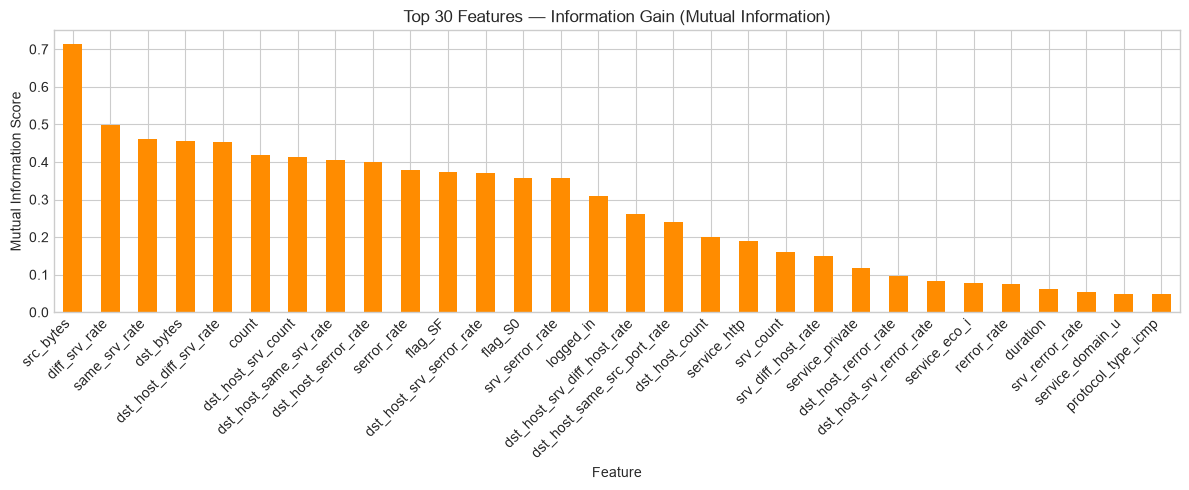

In [7]:
from sklearn.feature_selection import mutual_info_classif
X_train=X_train_p
k_mi = 30   # top-k features

mi_scores = mutual_info_classif(X_train, y_train, random_state=42)
mi_scores_series = pd.Series(mi_scores, index=X_train.columns)
mi_scores_sorted = mi_scores_series.sort_values(ascending=False)

selected_features_mi = mi_scores_sorted.head(k_mi).index.tolist()
print(f"Top {k_mi} features by Information Gain (Mutual Information):")
print(selected_features_mi)

# Plot
plt.figure(figsize=(12, 5))
mi_scores_sorted.head(k_mi).plot(kind='bar', color='darkorange', edgecolor='none')
plt.title(f'Top {k_mi} Features — Information Gain (Mutual Information)')
plt.xlabel('Feature')
plt.ylabel('Mutual Information Score')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


Top 30 features selected by Chi-Square test:
['flag_S0', 'dst_host_srv_serror_rate', 'srv_serror_rate', 'serror_rate', 'dst_host_serror_rate', 'logged_in', 'service_eco_i', 'flag_SF', 'dst_host_srv_count', 'service_http', 'dst_host_same_src_port_rate', 'dst_host_same_srv_rate', 'same_srv_rate', 'service_private', 'flag_RSTR', 'protocol_type_icmp', 'count', 'dst_host_diff_srv_rate', 'srv_rerror_rate', 'dst_host_srv_rerror_rate', 'rerror_rate', 'urgent', 'dst_host_rerror_rate', 'root_shell', 'dst_host_srv_diff_host_rate', 'srv_diff_host_rate', 'is_guest_login', 'service_domain_u', 'service_ftp_data', 'diff_srv_rate']


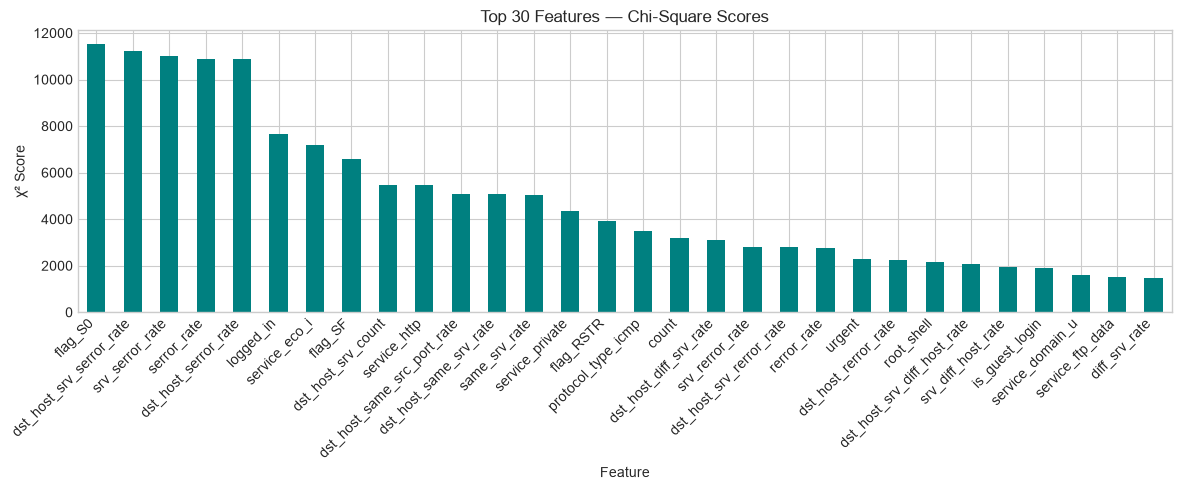

In [8]:
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.preprocessing import MinMaxScaler

X_train=X_train_p
X_test=X_test_p

k = 30  # number of top features to select

chi2_selector = SelectKBest(score_func=chi2, k=k)
chi2_selector.fit(X_train, y_train)

chi2_scores = pd.Series(chi2_selector.scores_, index=X_train.columns)
chi2_scores_sorted = chi2_scores.sort_values(ascending=False)

selected_features_chi2 = chi2_scores_sorted.head(k).index.tolist()
print(f"Top {k} features selected by Chi-Square test:")
print(selected_features_chi2)

# Plot top-k chi2 scores
plt.figure(figsize=(12, 5))
chi2_scores_sorted.head(k).plot(kind='bar', color='teal', edgecolor='none')
plt.title(f'Top {k} Features — Chi-Square Scores')
plt.xlabel('Feature')
plt.ylabel('χ² Score')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

 Running RFECV (Recursive Feature Elimination with Cross-Validation) using XGBoost

 Optimal number of features found by RFECV: 50
Selected Features: ['duration', 'src_bytes', 'dst_bytes', 'wrong_fragment', 'hot', 'num_failed_logins', 'logged_in', 'num_compromised', 'root_shell', 'num_root', 'num_file_creations', 'num_access_files', 'is_guest_login', 'count', 'srv_count', 'serror_rate', 'rerror_rate', 'srv_rerror_rate', 'same_srv_rate', 'diff_srv_rate', 'srv_diff_host_rate', 'dst_host_count', 'dst_host_srv_count', 'dst_host_same_srv_rate', 'dst_host_diff_srv_rate', 'dst_host_same_src_port_rate', 'dst_host_srv_diff_host_rate', 'dst_host_serror_rate', 'dst_host_srv_serror_rate', 'dst_host_rerror_rate', 'protocol_type_icmp', 'protocol_type_tcp', 'protocol_type_udp', 'service_domain_u', 'service_eco_i', 'service_ecr_i', 'service_finger', 'service_ftp_data', 'service_http', 'service_imap4', 'service_other', 'service_pm_dump', 'service_private', 'service_smtp', 'service_telnet', 'flag_REJ', 

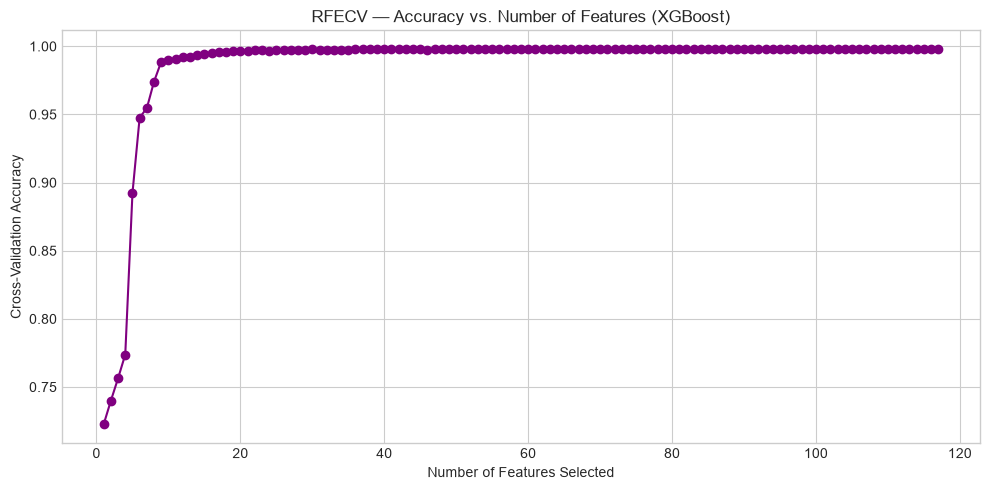


 RFECV Completed and data saved successfully!


In [9]:
import matplotlib.pyplot as plt
from xgboost import XGBClassifier  
from sklearn.feature_selection import RFECV
import joblib


estimator = XGBClassifier(random_state=42, n_jobs=1)

print(" Running RFECV (Recursive Feature Elimination with Cross-Validation) using XGBoost")
rfecv = RFECV(
    estimator=estimator,
    step=1,          
    cv=3,            
    scoring='accuracy',
    n_jobs=-1        
)

rfecv.fit(X_train_p, y_train)

print(f"\n Optimal number of features found by RFECV: {rfecv.n_features_}")

selected_features_rfecv = X_train_p.columns[rfecv.support_].tolist()
print(f"Selected Features: {selected_features_rfecv}")

plt.figure(figsize=(10, 5))
plt.plot(range(1, len(rfecv.cv_results_['mean_test_score']) + 1), rfecv.cv_results_['mean_test_score'], color='purple', marker='o')
plt.xlabel("Number of Features Selected")
plt.ylabel("Cross-Validation Accuracy")
plt.title("RFECV — Accuracy vs. Number of Features (XGBoost)")
plt.grid(True)
plt.tight_layout()
plt.show()

X_train_rfecv = rfecv.transform(X_train_p)
X_test_rfecv  = rfecv.transform(X_test_p)

joblib.dump(X_train_rfecv, "X_train_rfecv_cic.pkl")
joblib.dump(X_test_rfecv, "X_test_rfecv_cic.pkl")
print("\n RFECV Completed and data saved successfully!")

In [10]:
import matplotlib.pyplot as plt
from xgboost import XGBClassifier 
from mlxtend.feature_selection import SequentialFeatureSelector as SFS



estimator = XGBClassifier(random_state=42, n_jobs=1)

print(" Running Forward Selection.")
forward_selector = SFS(
    estimator=estimator,
    k_features=20,       
    forward=True,        
    floating=False,
    scoring='accuracy',
    cv=3,                
    n_jobs=-1            
)

forward_selector.fit(X_train_p, y_train)

selected_features_forward = list(forward_selector.k_feature_names_)
print(f"\n Top 20 features selected by Forward Selection:")
print(selected_features_forward)

X_train_fwd = forward_selector.transform(X_train_p)
X_test_fwd  = forward_selector.transform(X_test_p)

joblib.dump(X_train_fwd, "X_train_forward_cic.pkl")
joblib.dump(X_test_fwd, "X_test_forward_cic.pkl")
print("\n Forward Selection Completed and data saved successfully!")

 Running Forward Selection.

 Top 20 features selected by Forward Selection:
['duration', 'src_bytes', 'dst_bytes', 'land', 'urgent', 'num_shells', 'is_host_login', 'count', 'serror_rate', 'rerror_rate', 'dst_host_count', 'dst_host_diff_srv_rate', 'dst_host_same_src_port_rate', 'dst_host_srv_serror_rate', 'protocol_type_icmp', 'service_IRC', 'service_Z39_50', 'service_discard', 'service_http', 'service_private']

 Forward Selection Completed and data saved successfully!


In [11]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

all_classes = le.transform(le.classes_)
CLASS_NAMES = list(le.classes_)

def evaluate(name, y_true, y_pred):
    
    acc     = accuracy_score(y_true, y_pred)
    prec    = precision_score(y_true, y_pred, average='weighted', zero_division=0)
    rec     = recall_score(y_true, y_pred, average='weighted', zero_division=0)
    f1      = f1_score(y_true, y_pred, average='weighted')
    f1_mac  = f1_score(y_true, y_pred, average='macro')

    print(f'\n=== {name} ===')
    print(f'Accuracy : {acc:.4f}   Precision : {prec:.4f}   Recall : {rec:.4f}   '
          f'Weighted F1 : {f1:.4f}   Macro F1: {f1_mac:.4f}')

    print(classification_report(y_true, y_pred, labels=all_classes, target_names=CLASS_NAMES))

    cm = confusion_matrix(y_true, y_pred, labels=all_classes)
    fig, ax = plt.subplots(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=ax)
    ax.set_title(f'{name} — Confusion Matrix')
    ax.set_xlabel('Predicted'); ax.set_ylabel('True')
    plt.tight_layout()
    plt.show()

    return acc, prec, rec, f1, f1_mac

RESULTS = {}

 Starting SVM Evaluation across ALL Feature Selection methods...

 Testing Feature Set: Full_Features (Features Count: 117)

 Linear SVM Training Time: 0.24 seconds
 Predict Time  : 0.0070 seconds

=== SVM (Linear) — Full_Features ===
Accuracy : 0.7399   Precision : 0.7152   Recall : 0.7399   Weighted F1 : 0.6961   Macro F1: 0.4843
              precision    recall  f1-score   support

         DoS       0.93      0.82      0.87      7458
      Normal       0.65      0.93      0.76      9711
       Probe       0.78      0.63      0.70      2421
         R2L       0.30      0.02      0.03      2754
         U2R       0.86      0.03      0.06       200

    accuracy                           0.74     22544
   macro avg       0.70      0.48      0.48     22544
weighted avg       0.72      0.74      0.70     22544



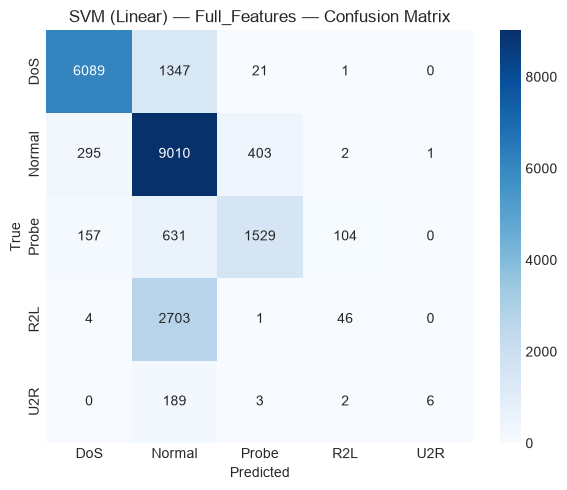


 RBF SVM Training Time: 1.81 seconds
 Predict Time  : 2.2697 seconds

=== SVM (RBF) — Full_Features ===
Accuracy : 0.7529   Precision : 0.8064   Recall : 0.7529   Weighted F1 : 0.7187   Macro F1: 0.5195
              precision    recall  f1-score   support

         DoS       0.95      0.80      0.87      7458
      Normal       0.66      0.93      0.77      9711
       Probe       0.75      0.72      0.74      2421
         R2L       0.99      0.09      0.17      2754
         U2R       0.86      0.03      0.06       200

    accuracy                           0.75     22544
   macro avg       0.84      0.51      0.52     22544
weighted avg       0.81      0.75      0.72     22544



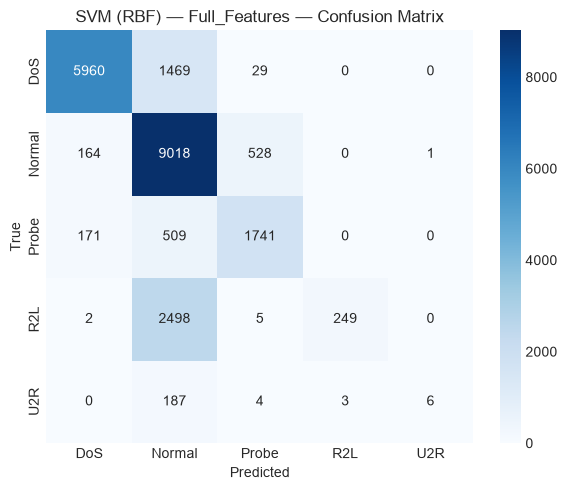

 Testing Feature Set: Filter_MI (Features Count: 30)

 Linear SVM Training Time: 0.21 seconds
 Predict Time  : 0.0040 seconds

=== SVM (Linear) — Filter_MI ===
Accuracy : 0.7207   Precision : 0.7082   Recall : 0.7207   Weighted F1 : 0.6728   Macro F1: 0.4559
              precision    recall  f1-score   support

         DoS       0.90      0.78      0.83      7458
      Normal       0.63      0.93      0.75      9711
       Probe       0.86      0.58      0.70      2421
         R2L       0.40      0.00      0.00      2754
         U2R       0.00      0.00      0.00       200

    accuracy                           0.72     22544
   macro avg       0.56      0.46      0.46     22544
weighted avg       0.71      0.72      0.67     22544



C:\Users\ASUS TUF\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\ASUS TUF\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\ASUS TUF\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


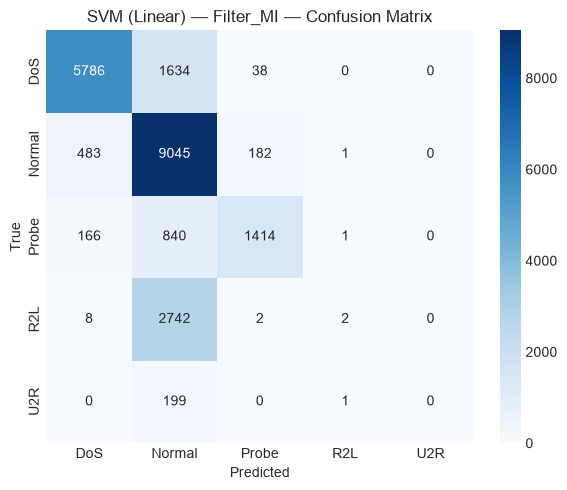


 RBF SVM Training Time: 0.93 seconds
 Predict Time  : 1.8786 seconds

=== SVM (RBF) — Filter_MI ===
Accuracy : 0.7247   Precision : 0.7412   Recall : 0.7247   Weighted F1 : 0.6780   Macro F1: 0.4730
              precision    recall  f1-score   support

         DoS       0.89      0.74      0.81      7458
      Normal       0.63      0.93      0.75      9711
       Probe       0.86      0.75      0.80      2421
         R2L       0.67      0.00      0.01      2754
         U2R       0.00      0.00      0.00       200

    accuracy                           0.72     22544
   macro avg       0.61      0.48      0.47     22544
weighted avg       0.74      0.72      0.68     22544



C:\Users\ASUS TUF\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\ASUS TUF\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\ASUS TUF\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


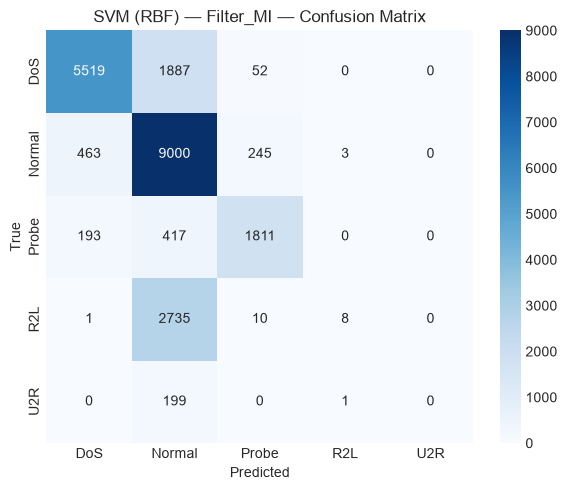

 Testing Feature Set: Filter_Chi2 (Features Count: 30)

 Linear SVM Training Time: 0.15 seconds
 Predict Time  : 0.0030 seconds

=== SVM (Linear) — Filter_Chi2 ===
Accuracy : 0.7171   Precision : 0.7765   Recall : 0.7171   Weighted F1 : 0.6704   Macro F1: 0.4691
              precision    recall  f1-score   support

         DoS       0.90      0.77      0.83      7458
      Normal       0.62      0.93      0.75      9711
       Probe       0.83      0.57      0.67      2421
         R2L       0.92      0.00      0.01      2754
         U2R       0.90      0.04      0.09       200

    accuracy                           0.72     22544
   macro avg       0.84      0.46      0.47     22544
weighted avg       0.78      0.72      0.67     22544



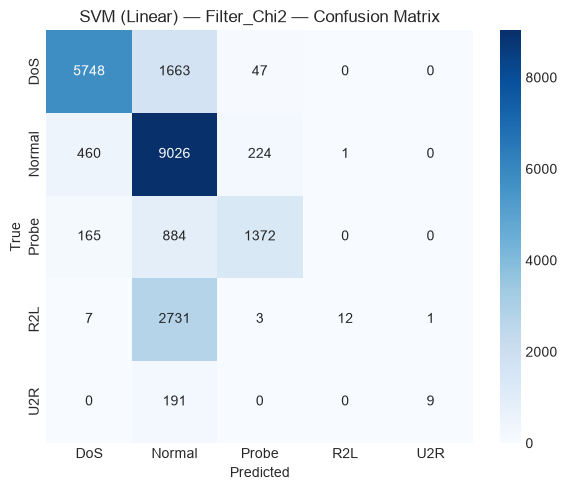


 RBF SVM Training Time: 0.94 seconds
 Predict Time  : 1.8245 seconds

=== SVM (RBF) — Filter_Chi2 ===
Accuracy : 0.7463   Precision : 0.7958   Recall : 0.7463   Weighted F1 : 0.7193   Macro F1: 0.5300
              precision    recall  f1-score   support

         DoS       0.90      0.78      0.83      7458
      Normal       0.65      0.93      0.77      9711
       Probe       0.83      0.65      0.73      2421
         R2L       0.98      0.16      0.28      2754
         U2R       0.67      0.02      0.04       200

    accuracy                           0.75     22544
   macro avg       0.81      0.51      0.53     22544
weighted avg       0.80      0.75      0.72     22544



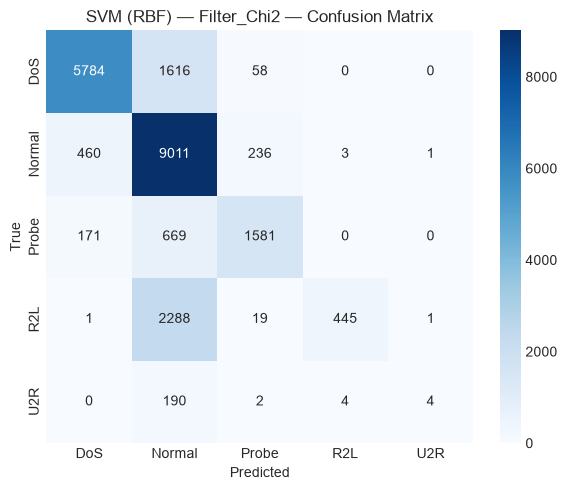

 Testing Feature Set: Wrapper_RFECV (Features Count: 50)

 Linear SVM Training Time: 0.18 seconds
 Predict Time  : 0.0033 seconds

=== SVM (Linear) — Wrapper_RFECV ===
Accuracy : 0.7417   Precision : 0.7144   Recall : 0.7417   Weighted F1 : 0.6966   Macro F1: 0.4777
              precision    recall  f1-score   support

         DoS       0.91      0.82      0.86      7458
      Normal       0.65      0.93      0.77      9711
       Probe       0.80      0.65      0.72      2421
         R2L       0.33      0.02      0.03      2754
         U2R       0.50      0.01      0.01       200

    accuracy                           0.74     22544
   macro avg       0.64      0.48      0.48     22544
weighted avg       0.71      0.74      0.70     22544



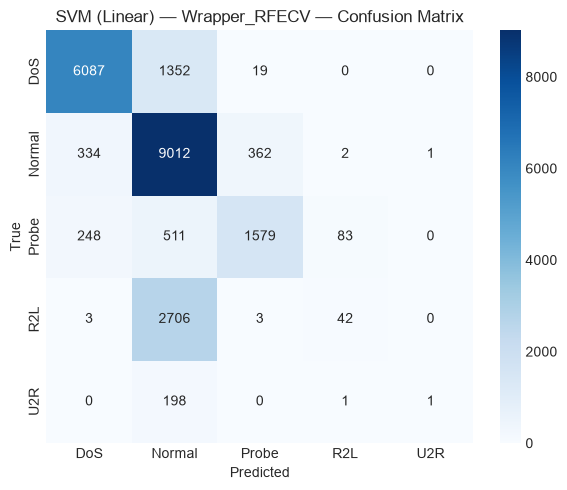


 RBF SVM Training Time: 0.89 seconds
 Predict Time  : 1.6547 seconds

=== SVM (RBF) — Wrapper_RFECV ===
Accuracy : 0.7433   Precision : 0.7995   Recall : 0.7433   Weighted F1 : 0.7107   Macro F1: 0.5078
              precision    recall  f1-score   support

         DoS       0.96      0.78      0.86      7458
      Normal       0.65      0.93      0.76      9711
       Probe       0.71      0.69      0.70      2421
         R2L       0.97      0.10      0.18      2754
         U2R       0.80      0.02      0.04       200

    accuracy                           0.74     22544
   macro avg       0.82      0.50      0.51     22544
weighted avg       0.80      0.74      0.71     22544



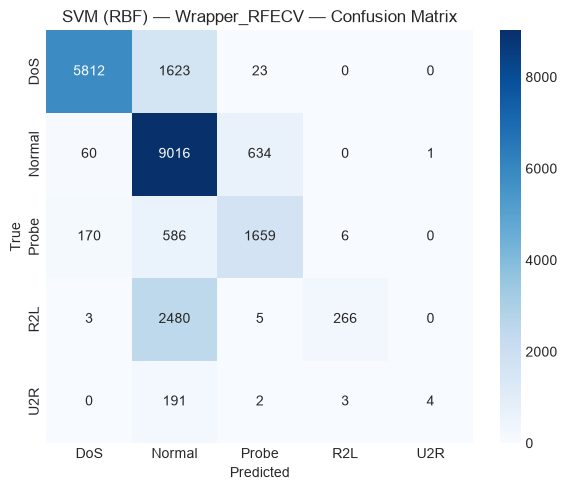

 Testing Feature Set: Wrapper_Forward (Features Count: 20)

 Linear SVM Training Time: 0.11 seconds
 Predict Time  : 0.0026 seconds

=== SVM (Linear) — Wrapper_Forward ===
Accuracy : 0.7237   Precision : 0.6530   Recall : 0.7237   Weighted F1 : 0.6730   Macro F1: 0.4659
              precision    recall  f1-score   support

         DoS       0.85      0.80      0.82      7458
      Normal       0.65      0.92      0.77      9711
       Probe       0.78      0.57      0.66      2421
         R2L       0.00      0.00      0.00      2754
         U2R       0.90      0.04      0.09       200

    accuracy                           0.72     22544
   macro avg       0.64      0.47      0.47     22544
weighted avg       0.65      0.72      0.67     22544



C:\Users\ASUS TUF\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\ASUS TUF\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\ASUS TUF\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


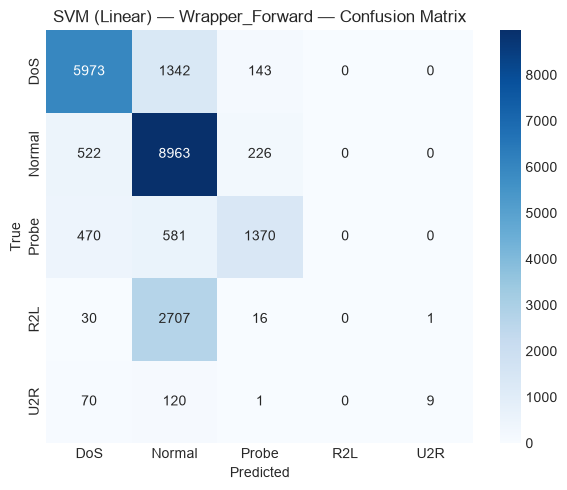


 RBF SVM Training Time: 1.57 seconds
 Predict Time  : 2.2252 seconds

=== SVM (RBF) — Wrapper_Forward ===
Accuracy : 0.7064   Precision : 0.7441   Recall : 0.7064   Weighted F1 : 0.6585   Macro F1: 0.4439
              precision    recall  f1-score   support

         DoS       0.89      0.76      0.82      7458
      Normal       0.62      0.93      0.74      9711
       Probe       0.80      0.53      0.64      2421
         R2L       0.75      0.00      0.00      2754
         U2R       0.67      0.01      0.02       200

    accuracy                           0.71     22544
   macro avg       0.75      0.44      0.44     22544
weighted avg       0.74      0.71      0.66     22544



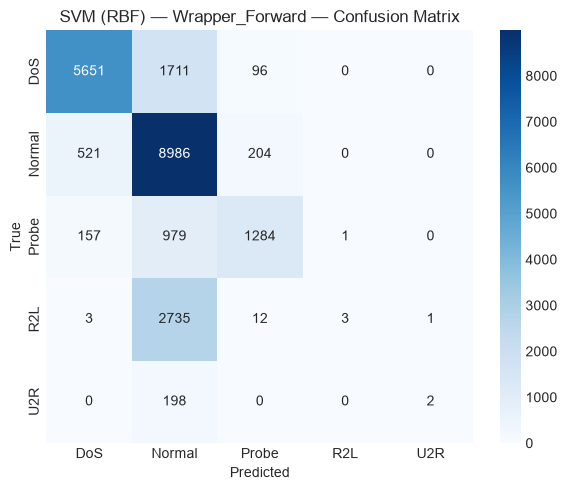


 All SVM models trained and evaluated successfully!


In [12]:
from sklearn.svm import SVC, LinearSVC
from sklearn.pipeline import Pipeline
import time


def _make_linear_svc():
    return Pipeline([
        ('clf', LinearSVC(C=1.0, max_iter=2000 , random_state=42)),
    ])
def _make_rbf_svc():
    return Pipeline([
        ('clf', SVC(kernel='rbf', C=10, gamma='scale',
                    decision_function_shape='ovr', random_state=42)),
    ])

FEATURE_SETS = {
    'Full_Features': (X_train_p, X_test_p),
    'Filter_MI': (X_train_p[selected_features_mi], X_test_p[selected_features_mi]),
    'Filter_Chi2': (X_train_p[selected_features_chi2], X_test_p[selected_features_chi2]),
    'Wrapper_RFECV': (X_train_rfecv, X_test_rfecv),
    'Wrapper_Forward': (X_train_fwd, X_test_fwd)
}

print(" Starting SVM Evaluation across ALL Feature Selection methods...\n")

for fs_name, (X_tr, X_te) in FEATURE_SETS.items():
    print(f"{'='*60}")
    print(f" Testing Feature Set: {fs_name} (Features Count: {X_tr.shape[1]})")
    print(f"{'='*60}")
    
    for kind, factory in [('Linear', _make_linear_svc), ('RBF', _make_rbf_svc)]:
        clf = factory()
        
        start_time = time.time()
        clf.fit(X_tr, y_train)
        train_time = time.time() - start_time
        start_pred = time.time()
        
        y_pred = clf.predict(X_te)
        pred_time = time.time() - start_pred
        
        label = f'SVM ({kind}) — {fs_name}'
        print(f"\n {kind} SVM Training Time: {train_time:.2f} seconds")
        print(f" Predict Time  : {pred_time:.4f} seconds")
        acc, prec, rec, f1, macro = evaluate(label, y_test, y_pred)

        
        RESULTS[label] =  {'Accuracy': acc,'Weighted F1': f1,'Macro F1': macro,'Train Time (s)': train_time,    'Predict Time (s)': pred_time    
                }

print("\n All SVM models trained and evaluated successfully!")

 Starting MLP Evaluation across ALL Feature Selection methods

Testing Feature Set: Full_Features (Features Count: 117)
Iteration 1, loss = 0.37489005
Validation score: 0.975794
Iteration 2, loss = 0.09512527
Validation score: 0.980952
Iteration 3, loss = 0.06838165
Validation score: 0.988095
Iteration 4, loss = 0.05728167
Validation score: 0.986905
Iteration 5, loss = 0.04963742
Validation score: 0.988095
Iteration 6, loss = 0.04509195
Validation score: 0.989286
Iteration 7, loss = 0.04075815
Validation score: 0.985714
Iteration 8, loss = 0.03784165
Validation score: 0.989683
Iteration 9, loss = 0.03565960
Validation score: 0.990476
Iteration 10, loss = 0.03285147
Validation score: 0.991270
Iteration 11, loss = 0.03167984
Validation score: 0.994048
Iteration 12, loss = 0.02934155
Validation score: 0.990873
Iteration 13, loss = 0.02720227
Validation score: 0.992460
Iteration 14, loss = 0.02681250
Validation score: 0.991667
Iteration 15, loss = 0.02433147
Validation score: 0.992063
Iter

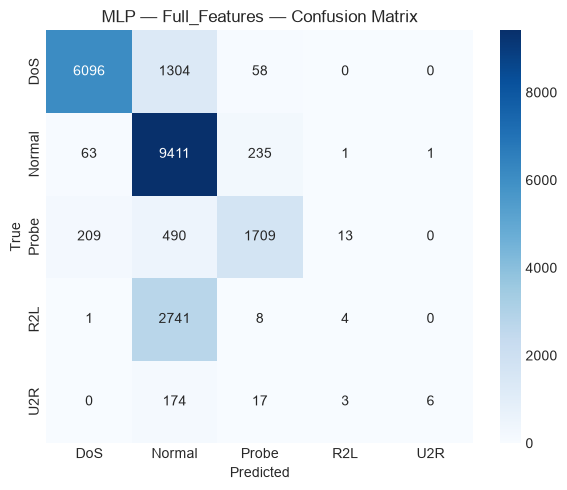

Testing Feature Set: Filter_MI (Features Count: 30)

 MLP Training Time: 6.61 seconds

 MLP predict Time: 0.03 seconds

=== MLP — Filter_MI ===
Accuracy : 0.7517   Precision : 0.7175   Recall : 0.7517   Weighted F1 : 0.7029   Macro F1: 0.4799
              precision    recall  f1-score   support

         DoS       0.96      0.78      0.86      7458
      Normal       0.65      0.97      0.78      9711
       Probe       0.82      0.70      0.76      2421
         R2L       0.25      0.00      0.00      2754
         U2R       0.00      0.00      0.00       200

    accuracy                           0.75     22544
   macro avg       0.54      0.49      0.48     22544
weighted avg       0.72      0.75      0.70     22544



C:\Users\ASUS TUF\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\ASUS TUF\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\ASUS TUF\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


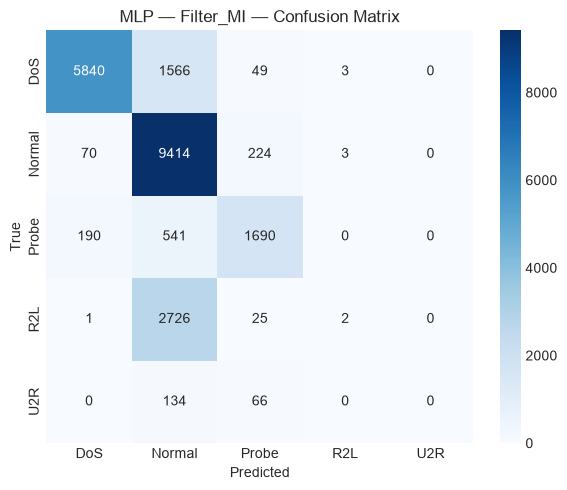

Testing Feature Set: Filter_Chi2 (Features Count: 30)

 MLP Training Time: 9.11 seconds

 MLP predict Time: 0.02 seconds

=== MLP — Filter_Chi2 ===
Accuracy : 0.7833   Precision : 0.8255   Recall : 0.7833   Weighted F1 : 0.7598   Macro F1: 0.5661
              precision    recall  f1-score   support

         DoS       0.94      0.83      0.88      7458
      Normal       0.69      0.97      0.81      9711
       Probe       0.84      0.59      0.69      2421
         R2L       0.97      0.23      0.38      2754
         U2R       0.89      0.04      0.08       200

    accuracy                           0.78     22544
   macro avg       0.87      0.53      0.57     22544
weighted avg       0.83      0.78      0.76     22544



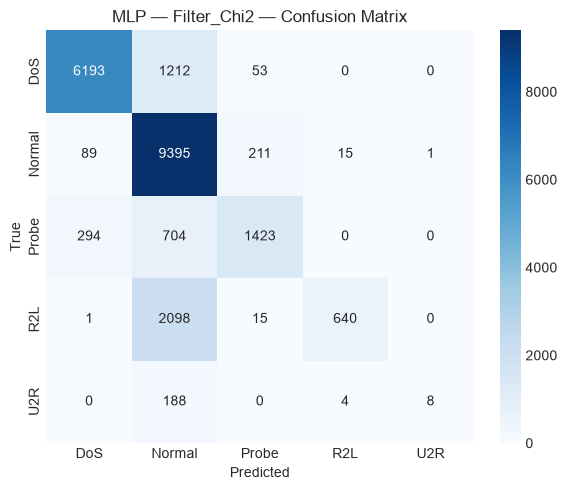

Testing Feature Set: Wrapper_RFECV (Features Count: 50)

 MLP Training Time: 5.64 seconds

 MLP predict Time: 0.02 seconds

=== MLP — Wrapper_RFECV ===
Accuracy : 0.7731   Precision : 0.8139   Recall : 0.7731   Weighted F1 : 0.7301   Macro F1: 0.5301
              precision    recall  f1-score   support

         DoS       0.96      0.83      0.89      7458
      Normal       0.67      0.97      0.80      9711
       Probe       0.85      0.68      0.76      2421
         R2L       0.88      0.04      0.07      2754
         U2R       0.70      0.07      0.13       200

    accuracy                           0.77     22544
   macro avg       0.81      0.52      0.53     22544
weighted avg       0.81      0.77      0.73     22544



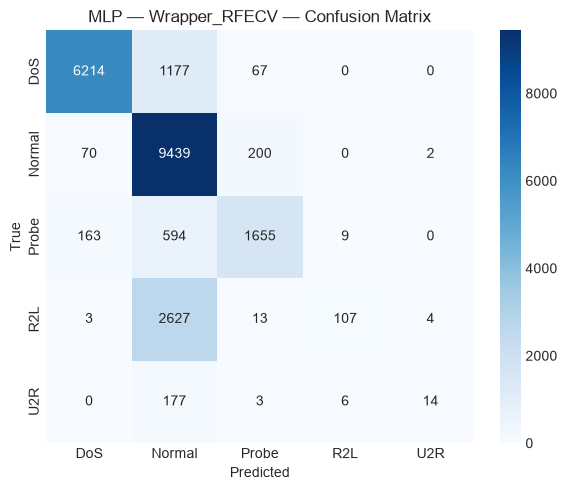

Testing Feature Set: Wrapper_Forward (Features Count: 20)

 MLP Training Time: 5.43 seconds

 MLP predict Time: 0.02 seconds

=== MLP — Wrapper_Forward ===
Accuracy : 0.7293   Precision : 0.7677   Recall : 0.7293   Weighted F1 : 0.6962   Macro F1: 0.4889
              precision    recall  f1-score   support

         DoS       0.90      0.78      0.83      7458
      Normal       0.64      0.92      0.76      9711
       Probe       0.79      0.56      0.66      2421
         R2L       0.91      0.11      0.20      2754
         U2R       0.00      0.00      0.00       200

    accuracy                           0.73     22544
   macro avg       0.65      0.48      0.49     22544
weighted avg       0.77      0.73      0.70     22544



C:\Users\ASUS TUF\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\ASUS TUF\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\ASUS TUF\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


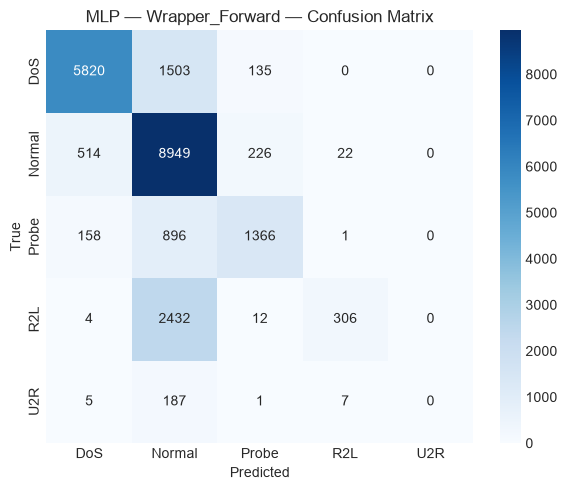


 All MLP models trained and evaluated successfully


In [13]:
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
import time

def _make_mlp(verbose=False):
    return Pipeline([
        ('clf', MLPClassifier(
            hidden_layer_sizes=(128, 64),
            activation='relu', solver='adam',
            alpha=1e-4, batch_size=256,
            learning_rate_init=1e-3, max_iter=50,
            early_stopping=True, validation_fraction=0.1,
            n_iter_no_change=5, random_state=42, verbose=verbose)),
    ])

print(" Starting MLP Evaluation across ALL Feature Selection methods\n")

for fs_name, (X_tr, X_te) in FEATURE_SETS.items():
    print(f"{'='*60}")
    print(f"Testing Feature Set: {fs_name} (Features Count: {X_tr.shape[1]})")
    print(f"{'='*60}")
    
    is_baseline = (fs_name == 'Full_Features')
    mlp_pipeline = _make_mlp(verbose=is_baseline)
    
    
    start_time = time.time()
    mlp_pipeline.fit(X_tr, y_train)
    train_time = time.time() - start_time
    start_pred = time.time()   
    y_pred = mlp_pipeline.predict(X_te)
    pred_time = time.time() - start_pred
    label = f'MLP — {fs_name}'
    print(f"\n MLP Training Time: {train_time:.2f} seconds")
    print(f"\n MLP predict Time: {pred_time:.2f} seconds")

    
    acc, prec, rec, f1, macro = evaluate(label, y_test, y_pred)
    
   
    RESULTS[label] =  {'Accuracy': acc,'Weighted F1': f1,'Macro F1': macro,'Train Time (s)': train_time,    'Predict Time (s)': pred_time    
                }

print("\n All MLP models trained and evaluated successfully")

 Starting XGBoost Baseline (Without GridSearchCV) across ALL Feature Sets...

 Testing XGBoost Baseline on Feature Set: Full_Features (Features Count: 117)

 Training Time: 0.78 seconds

 predict Time: 0.03 seconds

=== XGBoost (Baseline) — Full_Features ===
Accuracy : 0.7774   Precision : 0.8288   Recall : 0.7774   Weighted F1 : 0.7473   Macro F1: 0.5429
              precision    recall  f1-score   support

         DoS       0.96      0.83      0.89      7458
      Normal       0.68      0.97      0.80      9711
       Probe       0.85      0.59      0.70      2421
         R2L       0.99      0.15      0.26      2754
         U2R       0.75      0.03      0.06       200

    accuracy                           0.78     22544
   macro avg       0.85      0.52      0.54     22544
weighted avg       0.83      0.78      0.75     22544



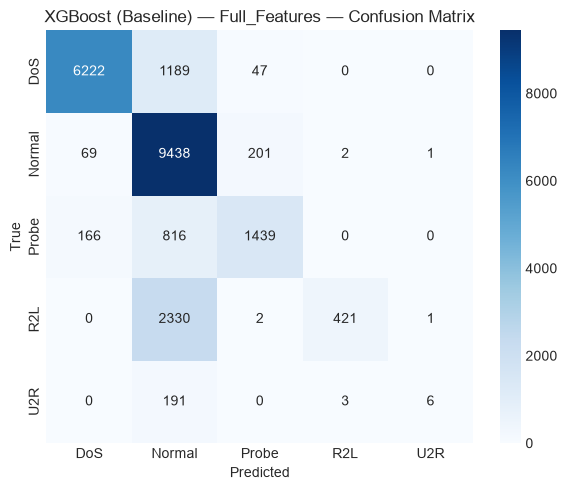

 Testing XGBoost Baseline on Feature Set: Filter_MI (Features Count: 30)

 Training Time: 0.40 seconds

 predict Time: 0.02 seconds

=== XGBoost (Baseline) — Filter_MI ===
Accuracy : 0.7614   Precision : 0.7969   Recall : 0.7614   Weighted F1 : 0.7120   Macro F1: 0.4868
              precision    recall  f1-score   support

         DoS       0.96      0.84      0.90      7458
      Normal       0.66      0.97      0.79      9711
       Probe       0.85      0.59      0.70      2421
         R2L       0.83      0.00      0.01      2754
         U2R       0.21      0.03      0.04       200

    accuracy                           0.76     22544
   macro avg       0.70      0.49      0.49     22544
weighted avg       0.80      0.76      0.71     22544



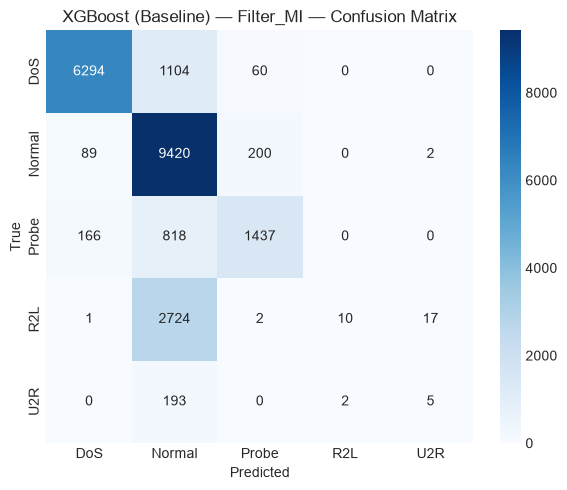

 Testing XGBoost Baseline on Feature Set: Filter_Chi2 (Features Count: 30)

 Training Time: 0.41 seconds

 predict Time: 0.02 seconds

=== XGBoost (Baseline) — Filter_Chi2 ===
Accuracy : 0.7430   Precision : 0.8071   Recall : 0.7430   Weighted F1 : 0.7138   Macro F1: 0.5097
              precision    recall  f1-score   support

         DoS       0.96      0.75      0.84      7458
      Normal       0.64      0.97      0.77      9711
       Probe       0.86      0.55      0.67      2421
         R2L       0.96      0.15      0.26      2754
         U2R       0.50      0.01      0.01       200

    accuracy                           0.74     22544
   macro avg       0.78      0.48      0.51     22544
weighted avg       0.81      0.74      0.71     22544



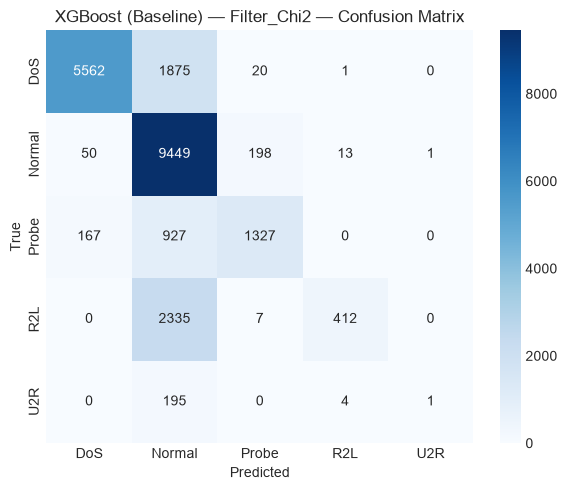

 Testing XGBoost Baseline on Feature Set: Wrapper_RFECV (Features Count: 50)

 Training Time: 0.47 seconds

 predict Time: 0.01 seconds

=== XGBoost (Baseline) — Wrapper_RFECV ===
Accuracy : 0.7779   Precision : 0.8283   Recall : 0.7779   Weighted F1 : 0.7476   Macro F1: 0.5409
              precision    recall  f1-score   support

         DoS       0.96      0.84      0.90      7458
      Normal       0.68      0.97      0.80      9711
       Probe       0.84      0.60      0.70      2421
         R2L       0.99      0.15      0.26      2754
         U2R       0.71      0.03      0.05       200

    accuracy                           0.78     22544
   macro avg       0.84      0.52      0.54     22544
weighted avg       0.83      0.78      0.75     22544



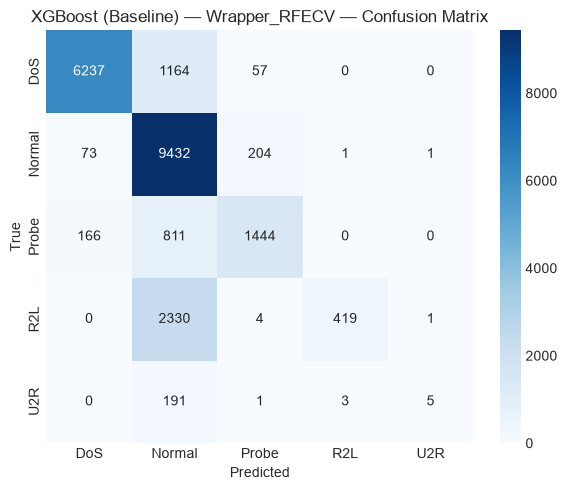

 Testing XGBoost Baseline on Feature Set: Wrapper_Forward (Features Count: 20)

 Training Time: 0.31 seconds

 predict Time: 0.01 seconds

=== XGBoost (Baseline) — Wrapper_Forward ===
Accuracy : 0.7677   Precision : 0.8262   Recall : 0.7677   Weighted F1 : 0.7267   Macro F1: 0.5124
              precision    recall  f1-score   support

         DoS       0.98      0.84      0.90      7458
      Normal       0.66      0.97      0.79      9711
       Probe       0.82      0.60      0.70      2421
         R2L       0.99      0.06      0.11      2754
         U2R       0.88      0.04      0.07       200

    accuracy                           0.77     22544
   macro avg       0.87      0.50      0.51     22544
weighted avg       0.83      0.77      0.73     22544



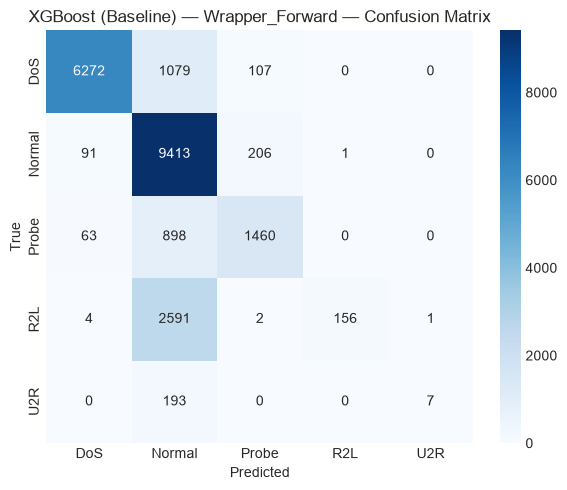


 All XGBoost baseline models evaluated successfully!


In [14]:
import xgboost as xgb
import time

print(" Starting XGBoost Baseline (Without GridSearchCV) across ALL Feature Sets...\n")


for fs_name, (X_tr, X_te) in FEATURE_SETS.items():
    print(f"{'='*60}")
    print(f" Testing XGBoost Baseline on Feature Set: {fs_name} (Features Count: {X_tr.shape[1]})")
    print(f"{'='*60}")
    
    
    xgb_baseline = xgb.XGBClassifier(verbosity=0, random_state=42, n_jobs=-1)
    
    start_time = time.time()
    xgb_baseline.fit(X_tr, y_train)
    train_time = time.time() - start_time
    start_pred = time.time()   
    y_pred = xgb_baseline.predict(X_te)
    pred_time = time.time() - start_pred
    
    label = f'XGBoost (Baseline) — {fs_name}'
    print(f"\n Training Time: {train_time:.2f} seconds")
    print(f"\n predict Time: {pred_time:.2f} seconds")

 
    acc, prec, rec, f1, macro = evaluate(label, y_test, y_pred)
    RESULTS[label] =  {'Accuracy': acc,'Weighted F1': f1,'Macro F1': macro,'Train Time (s)': train_time,    'Predict Time (s)': pred_time    
                }

print("\n All XGBoost baseline models evaluated successfully!")

 Starting SVM + GridSearchCV Evaluation ON SELECTED FEATURES ONLY...

 Testing SVM (GridSearchCV) on Feature Set: Filter_MI
 Training Time: 155.96s |  Best Params: {'clf__C': 100, 'clf__class_weight': 'balanced', 'clf__gamma': 0.5, 'clf__kernel': 'rbf'}

 predict Time: 1.74 seconds

=== SVM (Optimized) — Filter_MI ===
Accuracy : 0.7281   Precision : 0.7657   Recall : 0.7281   Weighted F1 : 0.6983   Macro F1: 0.4982
              precision    recall  f1-score   support

         DoS       0.92      0.77      0.83      7458
      Normal       0.64      0.92      0.76      9711
       Probe       0.75      0.58      0.66      2421
         R2L       0.86      0.12      0.21      2754
         U2R       0.07      0.02      0.03       200

    accuracy                           0.73     22544
   macro avg       0.65      0.48      0.50     22544
weighted avg       0.77      0.73      0.70     22544



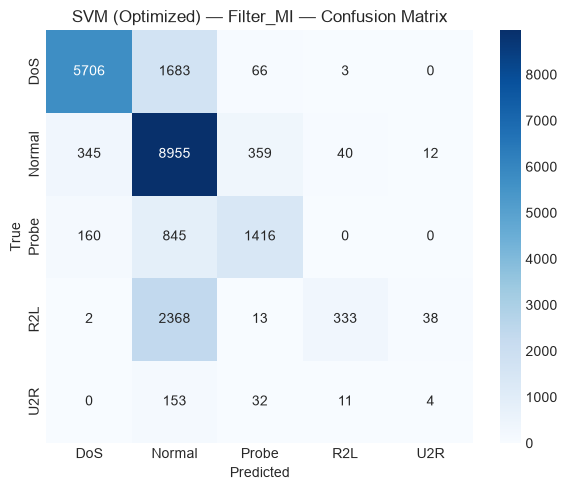

 Testing SVM (GridSearchCV) on Feature Set: Filter_Chi2
 Training Time: 140.95s |  Best Params: {'clf__C': 100, 'clf__class_weight': 'balanced', 'clf__gamma': 0.5, 'clf__kernel': 'rbf'}

 predict Time: 2.18 seconds

=== SVM (Optimized) — Filter_Chi2 ===
Accuracy : 0.7483   Precision : 0.7719   Recall : 0.7483   Weighted F1 : 0.7260   Macro F1: 0.5391
              precision    recall  f1-score   support

         DoS       0.90      0.79      0.84      7458
      Normal       0.67      0.92      0.77      9711
       Probe       0.78      0.61      0.68      2421
         R2L       0.83      0.21      0.33      2754
         U2R       0.17      0.04      0.06       200

    accuracy                           0.75     22544
   macro avg       0.67      0.51      0.54     22544
weighted avg       0.77      0.75      0.73     22544



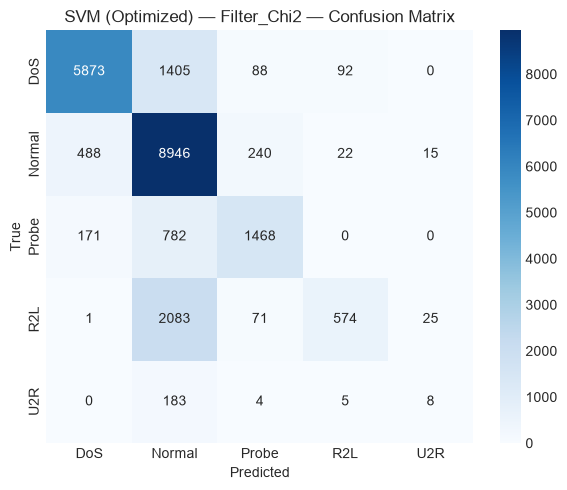

 Testing SVM (GridSearchCV) on Feature Set: Wrapper_RFECV
 Training Time: 174.86s |  Best Params: {'clf__C': 100, 'clf__class_weight': 'balanced', 'clf__gamma': 0.5, 'clf__kernel': 'rbf'}

 predict Time: 1.55 seconds

=== SVM (Optimized) — Wrapper_RFECV ===
Accuracy : 0.7752   Precision : 0.7798   Recall : 0.7752   Weighted F1 : 0.7522   Macro F1: 0.5504
              precision    recall  f1-score   support

         DoS       0.97      0.80      0.88      7458
      Normal       0.70      0.96      0.81      9711
       Probe       0.77      0.66      0.71      2421
         R2L       0.61      0.20      0.30      2754
         U2R       0.18      0.04      0.06       200

    accuracy                           0.78     22544
   macro avg       0.65      0.53      0.55     22544
weighted avg       0.78      0.78      0.75     22544



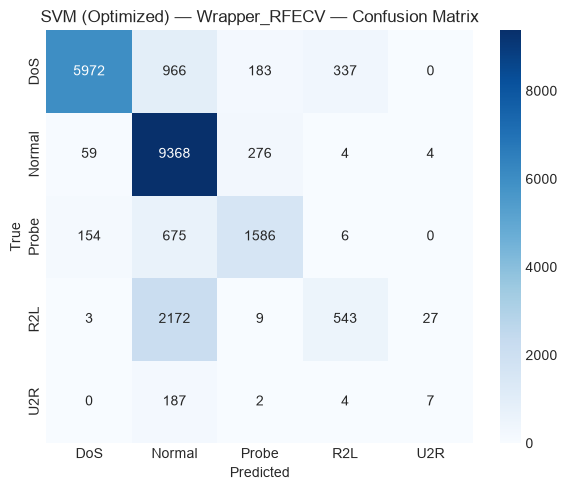

 Testing SVM (GridSearchCV) on Feature Set: Wrapper_Forward
 Training Time: 201.48s |  Best Params: {'clf__C': 100, 'clf__class_weight': 'balanced', 'clf__gamma': 'scale', 'clf__kernel': 'rbf'}

 predict Time: 4.83 seconds

=== SVM (Optimized) — Wrapper_Forward ===
Accuracy : 0.7237   Precision : 0.7530   Recall : 0.7237   Weighted F1 : 0.7263   Macro F1: 0.5337
              precision    recall  f1-score   support

         DoS       0.89      0.77      0.83      7458
      Normal       0.71      0.86      0.78      9711
       Probe       0.79      0.61      0.69      2421
         R2L       0.53      0.25      0.34      2754
         U2R       0.02      0.09      0.03       200

    accuracy                           0.72     22544
   macro avg       0.59      0.52      0.53     22544
weighted avg       0.75      0.72      0.73     22544



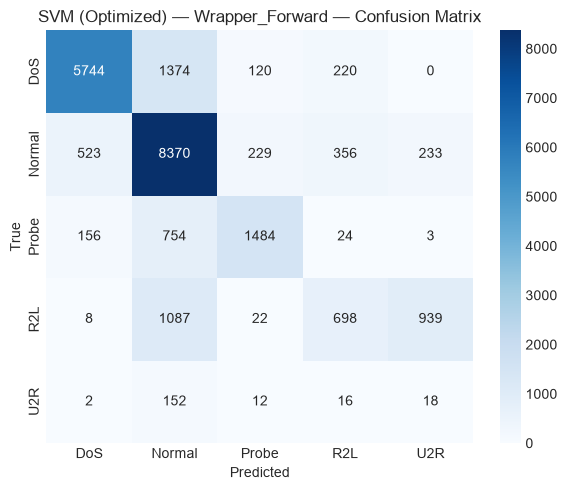


 GridSearchCV completed for selected features only!


In [15]:
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV, StratifiedKFold
import time

def _make_svc_pipeline():
    return Pipeline([('clf', SVC( random_state=42))])

param_grid_svm =  {
    'clf__C': [0.1, 1, 10, 100],
    'clf__gamma': ['scale', 'auto', 0.01, 0.1, 0.5],
    'clf__kernel': ['rbf', 'linear'],
    'clf__class_weight': ['balanced']
} 
sCV_svm = StratifiedKFold(n_splits=5, shuffle=True, random_state=1000)

print(" Starting SVM + GridSearchCV Evaluation ON SELECTED FEATURES ONLY...\n")

for fs_name, (X_tr, X_te) in FEATURE_SETS.items():
    
    #
    if fs_name == 'Full_Features':
        continue
        
    print(f"{'='*60}\n Testing SVM (GridSearchCV) on Feature Set: {fs_name}\n{'='*60}")

  
    grid_search = GridSearchCV(
        estimator=_make_svc_pipeline(),
        param_grid=param_grid_svm,
        cv=sCV_svm,
        scoring='f1_macro',
        n_jobs=-1
    )

    start_time = time.time()
    grid_search.fit(X_tr, y_train)
    train_time = time.time() - start_time

    print(f" Training Time: {train_time:.2f}s |  Best Params: {grid_search.best_params_}")
    start_pred = time.time()   
    y_pred = grid_search.best_estimator_.predict(X_te)
    pred_time = time.time() - start_pred

    label = f'SVM (Optimized) — {fs_name}'
    print(f"\n predict Time: {pred_time:.2f} seconds")
    acc, prec, rec, f1, macro = evaluate(label, y_test, y_pred)
    RESULTS[label] =  {'Accuracy': acc,'Weighted F1': f1,'Macro F1': macro,'Train Time (s)': train_time,    'Predict Time (s)': pred_time    
                ,'Best_Params': grid_search.best_params_}

print("\n GridSearchCV completed for selected features only!")


 Starting MLP + GridSearchCV Evaluation ON SELECTED FEATURES ONLY...

 Testing MLP (GridSearchCV) on Feature Set: Filter_MI
 Training Time: 67.63s |  Best Params: {'clf__activation': 'relu', 'clf__alpha': 0.001, 'clf__hidden_layer_sizes': (100, 50, 25), 'clf__learning_rate_init': 0.01}

 predict Time: 0.02 seconds

=== MLP (Optimized) — Filter_MI ===
Accuracy : 0.7291   Precision : 0.7417   Recall : 0.7291   Weighted F1 : 0.6819   Macro F1: 0.4697
              precision    recall  f1-score   support

         DoS       0.89      0.78      0.83      7458
      Normal       0.64      0.92      0.75      9711
       Probe       0.85      0.68      0.76      2421
         R2L       0.67      0.00      0.01      2754
         U2R       0.00      0.00      0.00       200

    accuracy                           0.73     22544
   macro avg       0.61      0.48      0.47     22544
weighted avg       0.74      0.73      0.68     22544



C:\Users\ASUS TUF\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\ASUS TUF\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\ASUS TUF\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


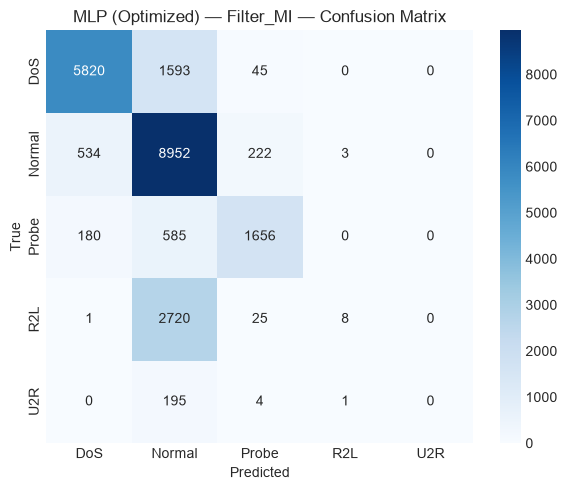

 Testing MLP (GridSearchCV) on Feature Set: Filter_Chi2
 Training Time: 70.73s |  Best Params: {'clf__activation': 'relu', 'clf__alpha': 0.0001, 'clf__hidden_layer_sizes': (100, 50, 25), 'clf__learning_rate_init': 0.01}

 predict Time: 0.02 seconds

=== MLP (Optimized) — Filter_Chi2 ===
Accuracy : 0.7724   Precision : 0.8251   Recall : 0.7724   Weighted F1 : 0.7471   Macro F1: 0.5635
              precision    recall  f1-score   support

         DoS       0.96      0.77      0.86      7458
      Normal       0.67      0.97      0.79      9711
       Probe       0.86      0.71      0.78      2421
         R2L       0.98      0.18      0.31      2754
         U2R       0.69      0.04      0.08       200

    accuracy                           0.77     22544
   macro avg       0.83      0.54      0.56     22544
weighted avg       0.83      0.77      0.75     22544



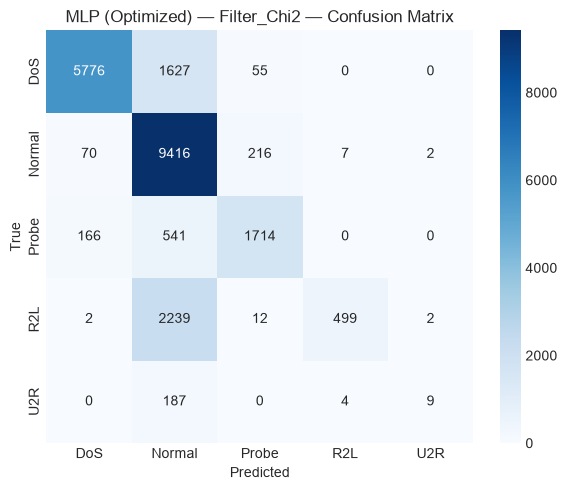

 Testing MLP (GridSearchCV) on Feature Set: Wrapper_RFECV
 Training Time: 77.59s |  Best Params: {'clf__activation': 'relu', 'clf__alpha': 0.001, 'clf__hidden_layer_sizes': (100,), 'clf__learning_rate_init': 0.01}

 predict Time: 0.01 seconds

=== MLP (Optimized) — Wrapper_RFECV ===
Accuracy : 0.7602   Precision : 0.8015   Recall : 0.7602   Weighted F1 : 0.7210   Macro F1: 0.5249
              precision    recall  f1-score   support

         DoS       0.96      0.79      0.86      7458
      Normal       0.66      0.97      0.79      9711
       Probe       0.84      0.69      0.76      2421
         R2L       0.82      0.06      0.11      2754
         U2R       0.85      0.06      0.10       200

    accuracy                           0.76     22544
   macro avg       0.83      0.51      0.52     22544
weighted avg       0.80      0.76      0.72     22544



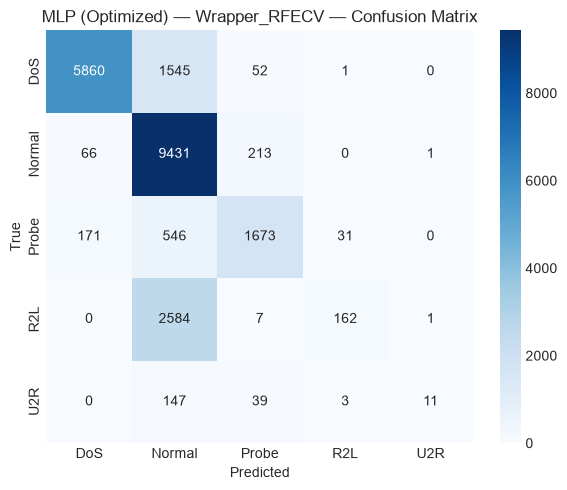

 Testing MLP (GridSearchCV) on Feature Set: Wrapper_Forward
 Training Time: 58.72s |  Best Params: {'clf__activation': 'relu', 'clf__alpha': 0.01, 'clf__hidden_layer_sizes': (120, 60), 'clf__learning_rate_init': 0.01}

 predict Time: 0.02 seconds

=== MLP (Optimized) — Wrapper_Forward ===
Accuracy : 0.7280   Precision : 0.7687   Recall : 0.7280   Weighted F1 : 0.6944   Macro F1: 0.4853
              precision    recall  f1-score   support

         DoS       0.90      0.79      0.84      7458
      Normal       0.64      0.92      0.75      9711
       Probe       0.80      0.53      0.64      2421
         R2L       0.91      0.11      0.20      2754
         U2R       0.00      0.00      0.00       200

    accuracy                           0.73     22544
   macro avg       0.65      0.47      0.49     22544
weighted avg       0.77      0.73      0.69     22544



C:\Users\ASUS TUF\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\ASUS TUF\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\ASUS TUF\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


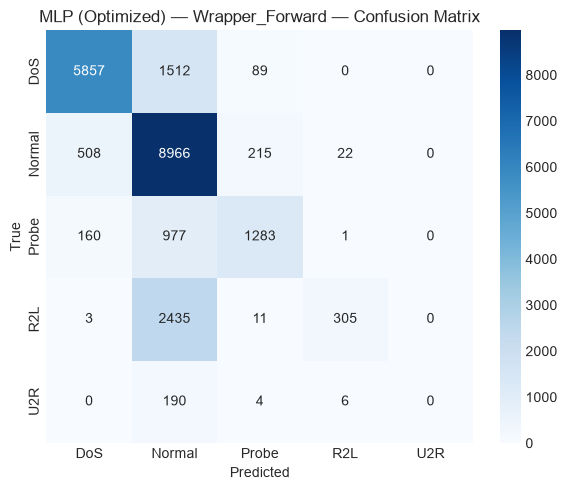


 GridSearchCV completed for selected features only (MLP)!


In [16]:
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV, StratifiedKFold
import time

def _make_mlp_pipeline():
    return Pipeline([('clf', MLPClassifier(
        solver='adam', 
        batch_size=256,
        max_iter=500,               # نضعها هنا كحد أقصى (لن يصل له غالباً بسبب التوقف المبكر)
        early_stopping=True,        # ميزة ممتازة تمنع الحفظ (Overfitting)
        validation_fraction=0.1,
        n_iter_no_change=5, 
        random_state=42
    ))])

param_grid_mlp = {
    'clf__hidden_layer_sizes': [(64,), (100,), (120, 60), (100, 50, 25)],
    'clf__activation': ['relu', 'tanh'],
    'clf__alpha': [0.0001, 0.001, 0.01],
    'clf__learning_rate_init': [0.001, 0.01]
}
sCV_mlp = StratifiedKFold(n_splits=5, shuffle=True, random_state=1000)  # cv=3 لتخفيف الكلفة الحسابية

print(" Starting MLP + GridSearchCV Evaluation ON SELECTED FEATURES ONLY...\n")

for fs_name, (X_tr, X_te) in FEATURE_SETS.items():
    
    if fs_name == 'Full_Features':
        continue
        
    print(f"{'='*60}\n Testing MLP (GridSearchCV) on Feature Set: {fs_name}\n{'='*60}")

    grid_search = GridSearchCV(
        estimator=_make_mlp_pipeline(),
        param_grid=param_grid_mlp,
        cv=sCV_mlp,
        scoring='f1_macro',
        n_jobs=-1  
    )

    start_time = time.time()
    grid_search.fit(X_tr, y_train)
    train_time = time.time() - start_time

    print(f" Training Time: {train_time:.2f}s |  Best Params: {grid_search.best_params_}")
    start_pred = time.time()   
    y_pred = grid_search.best_estimator_.predict(X_te)
    pred_time = time.time() - start_pred

   
    print(f"\n predict Time: {pred_time:.2f} seconds")
    label = f'MLP (Optimized) — {fs_name}'
    
    acc, prec, rec, f1, macro = evaluate(label, y_test, y_pred)
    RESULTS[label] =  {'Accuracy': acc,'Weighted F1': f1,'Macro F1': macro,'Train Time (s)': train_time,    'Predict Time (s)': pred_time    
                ,'Best_Params': grid_search.best_params_}

print("\n GridSearchCV completed for selected features only (MLP)!")

 Starting XGBoost + GridSearchCV Evaluation ON SELECTED FEATURES ONLY...

 Testing XGBoost on Feature Set: Filter_MI (Features Count: 30)
 Training Time: 114.42 seconds
 Best Hyperparameters found: {'colsample_bytree': 0.8, 'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 100, 'subsample': 0.8}

 predict Time: 0.02 seconds

=== XGBoost (Optimized) — Filter_MI ===
Accuracy : 0.7667   Precision : 0.8244   Recall : 0.7667   Weighted F1 : 0.7238   Macro F1: 0.5070
              precision    recall  f1-score   support

         DoS       0.96      0.84      0.90      7458
      Normal       0.67      0.97      0.79      9711
       Probe       0.83      0.60      0.70      2421
         R2L       1.00      0.05      0.09      2754
         U2R       0.86      0.03      0.06       200

    accuracy                           0.77     22544
   macro avg       0.86      0.50      0.51     22544
weighted avg       0.82      0.77      0.72     22544



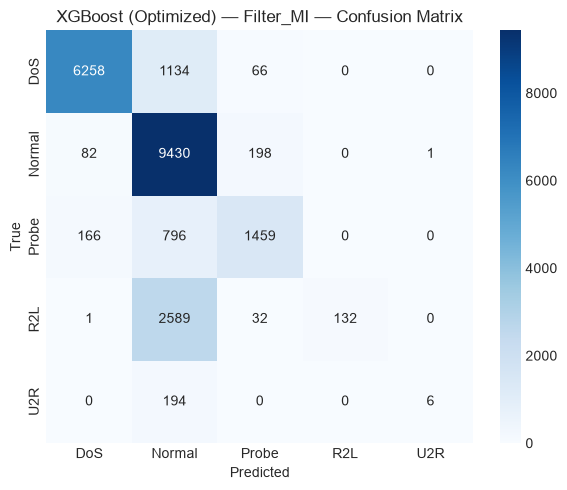

 Testing XGBoost on Feature Set: Filter_Chi2 (Features Count: 30)
 Training Time: 117.93 seconds
 Best Hyperparameters found: {'colsample_bytree': 0.8, 'learning_rate': 0.05, 'max_depth': 10, 'n_estimators': 300, 'subsample': 1.0}

 predict Time: 0.06 seconds

=== XGBoost (Optimized) — Filter_Chi2 ===
Accuracy : 0.7458   Precision : 0.8142   Recall : 0.7458   Weighted F1 : 0.7181   Macro F1: 0.5152
              precision    recall  f1-score   support

         DoS       0.96      0.75      0.84      7458
      Normal       0.64      0.97      0.77      9711
       Probe       0.86      0.55      0.67      2421
         R2L       0.97      0.17      0.28      2754
         U2R       1.00      0.01      0.01       200

    accuracy                           0.75     22544
   macro avg       0.89      0.49      0.52     22544
weighted avg       0.81      0.75      0.72     22544



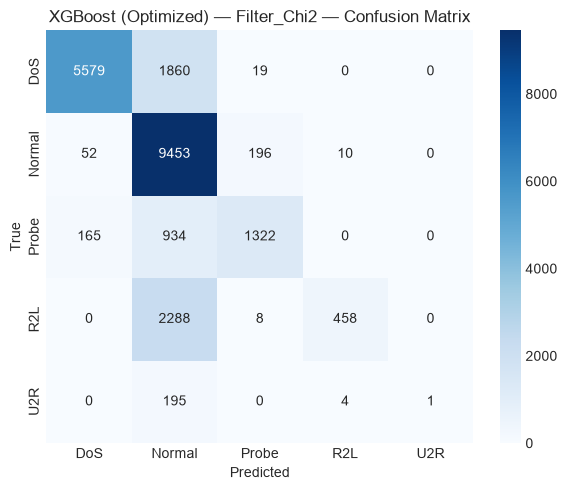

 Testing XGBoost on Feature Set: Wrapper_RFECV (Features Count: 50)
 Training Time: 135.57 seconds
 Best Hyperparameters found: {'colsample_bytree': 1.0, 'learning_rate': 0.05, 'max_depth': 4, 'n_estimators': 300, 'subsample': 0.8}

 predict Time: 0.03 seconds

=== XGBoost (Optimized) — Wrapper_RFECV ===
Accuracy : 0.7756   Precision : 0.8288   Recall : 0.7756   Weighted F1 : 0.7401   Macro F1: 0.5276
              precision    recall  f1-score   support

         DoS       0.96      0.85      0.90      7458
      Normal       0.67      0.97      0.80      9711
       Probe       0.85      0.60      0.70      2421
         R2L       0.99      0.11      0.19      2754
         U2R       0.83      0.03      0.05       200

    accuracy                           0.78     22544
   macro avg       0.86      0.51      0.53     22544
weighted avg       0.83      0.78      0.74     22544



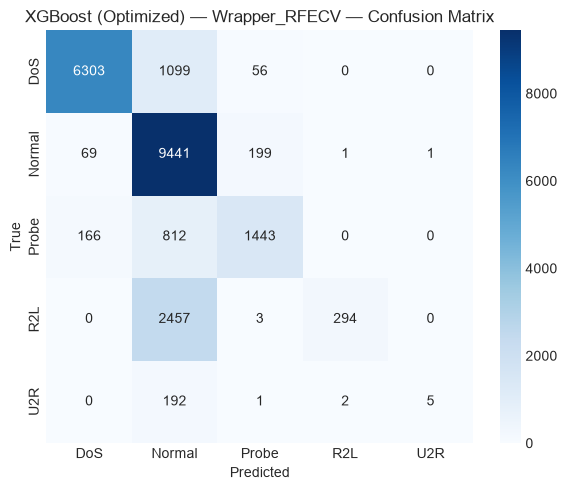

 Testing XGBoost on Feature Set: Wrapper_Forward (Features Count: 20)
 Training Time: 93.34 seconds
 Best Hyperparameters found: {'colsample_bytree': 1.0, 'learning_rate': 0.2, 'max_depth': 7, 'n_estimators': 100, 'subsample': 0.8}

 predict Time: 0.02 seconds

=== XGBoost (Optimized) — Wrapper_Forward ===
Accuracy : 0.7708   Precision : 0.8285   Recall : 0.7708   Weighted F1 : 0.7300   Macro F1: 0.5150
              precision    recall  f1-score   support

         DoS       0.98      0.85      0.91      7458
      Normal       0.67      0.97      0.79      9711
       Probe       0.83      0.60      0.70      2421
         R2L       0.99      0.06      0.11      2754
         U2R       0.88      0.04      0.07       200

    accuracy                           0.77     22544
   macro avg       0.87      0.50      0.51     22544
weighted avg       0.83      0.77      0.73     22544



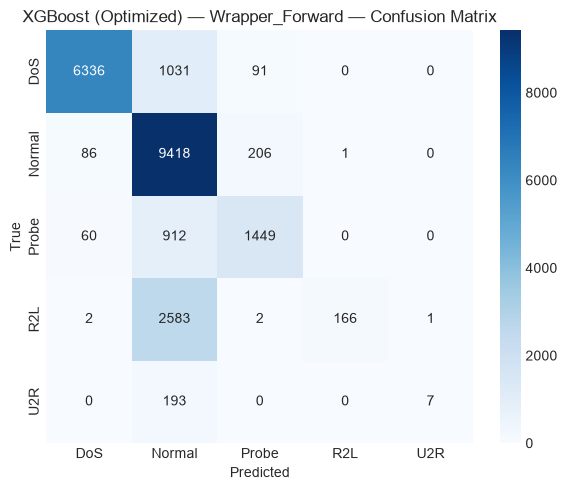


 All XGBoost models optimized and evaluated successfully on selected features!


In [17]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold
import xgboost as xgb
import time

param_grid_xgb = {
    'learning_rate': [0.05, 0.1, 0.2],       
    'n_estimators': [100, 300],              
    'max_depth': [4, 7, 10],                 
    'colsample_bytree': [0.8, 1.0],          
    'subsample': [0.8, 1.0]                 
}
# عدد الاحتمالات انخفض من 864 إلى 72 احتمال فقط! (أسرع بـ 12 مرة بنفس الدقة تقريباً)
sCV = StratifiedKFold(n_splits=5, shuffle=True, random_state=1000)

print(" Starting XGBoost + GridSearchCV Evaluation ON SELECTED FEATURES ONLY...\n")

for fs_name, (X_tr, X_te) in FEATURE_SETS.items():
    
    if fs_name == 'Full_Features':
        continue
        
    print(f"{'='*60}")
    print(f" Testing XGBoost on Feature Set: {fs_name} (Features Count: {X_tr.shape[1]})")
    print(f"{'='*60}")
    
    xgb_clf = xgb.XGBClassifier(verbosity=0, random_state=42, n_jobs=-1)
    
    grid_search = GridSearchCV(
        estimator=xgb_clf,
        param_grid=param_grid_xgb,
        cv=sCV,
        scoring='f1_macro',
        n_jobs=-1
    )
    
    start_time = time.time()
    grid_search.fit(X_tr, y_train)
    train_time = time.time() - start_time
    
    print(f" Training Time: {train_time:.2f} seconds")
    print(f" Best Hyperparameters found: {grid_search.best_params_}")
    
    best_model = grid_search.best_estimator_
    start_pred = time.time()   
    y_pred = best_model.predict(X_te)
    pred_time = time.time() - start_pred

   
    print(f"\n predict Time: {pred_time:.2f} seconds")
    label = f'XGBoost (Optimized) — {fs_name}'
    
    acc, prec, rec, f1, macro = evaluate(label, y_test, y_pred)
    
    RESULTS[label] =  {'Accuracy': acc,'Weighted F1': f1,'Macro F1': macro,'Train Time (s)': train_time,    'Predict Time (s)': pred_time    
                ,'Best_Params': grid_search.best_params_}

print("\n All XGBoost models optimized and evaluated successfully on selected features!")



                            Algorithm Accuracy Weighted F1 Macro F1 Train Time Predict Time
                    MLP — Filter_Chi2   0.7833      0.7598   0.5661      9.11s        0.02s
   XGBoost (Baseline) — Wrapper_RFECV   0.7779      0.7476   0.5409      0.47s        0.01s
   XGBoost (Baseline) — Full_Features   0.7774      0.7473   0.5429      0.78s        0.03s
  XGBoost (Optimized) — Wrapper_RFECV   0.7756      0.7401   0.5276    135.57s        0.03s
      SVM (Optimized) — Wrapper_RFECV   0.7752      0.7522   0.5504    174.86s        1.55s
                  MLP — Wrapper_RFECV   0.7731      0.7301   0.5301      5.64s        0.02s
        MLP (Optimized) — Filter_Chi2   0.7724      0.7471   0.5635     70.73s        0.02s
XGBoost (Optimized) — Wrapper_Forward   0.7708      0.7300   0.5150     93.34s        0.02s
 XGBoost (Baseline) — Wrapper_Forward   0.7677      0.7267   0.5124      0.31s        0.01s
      XGBoost (Optimized) — Filter_MI   0.7667      0.7238   0.5070    114.42s

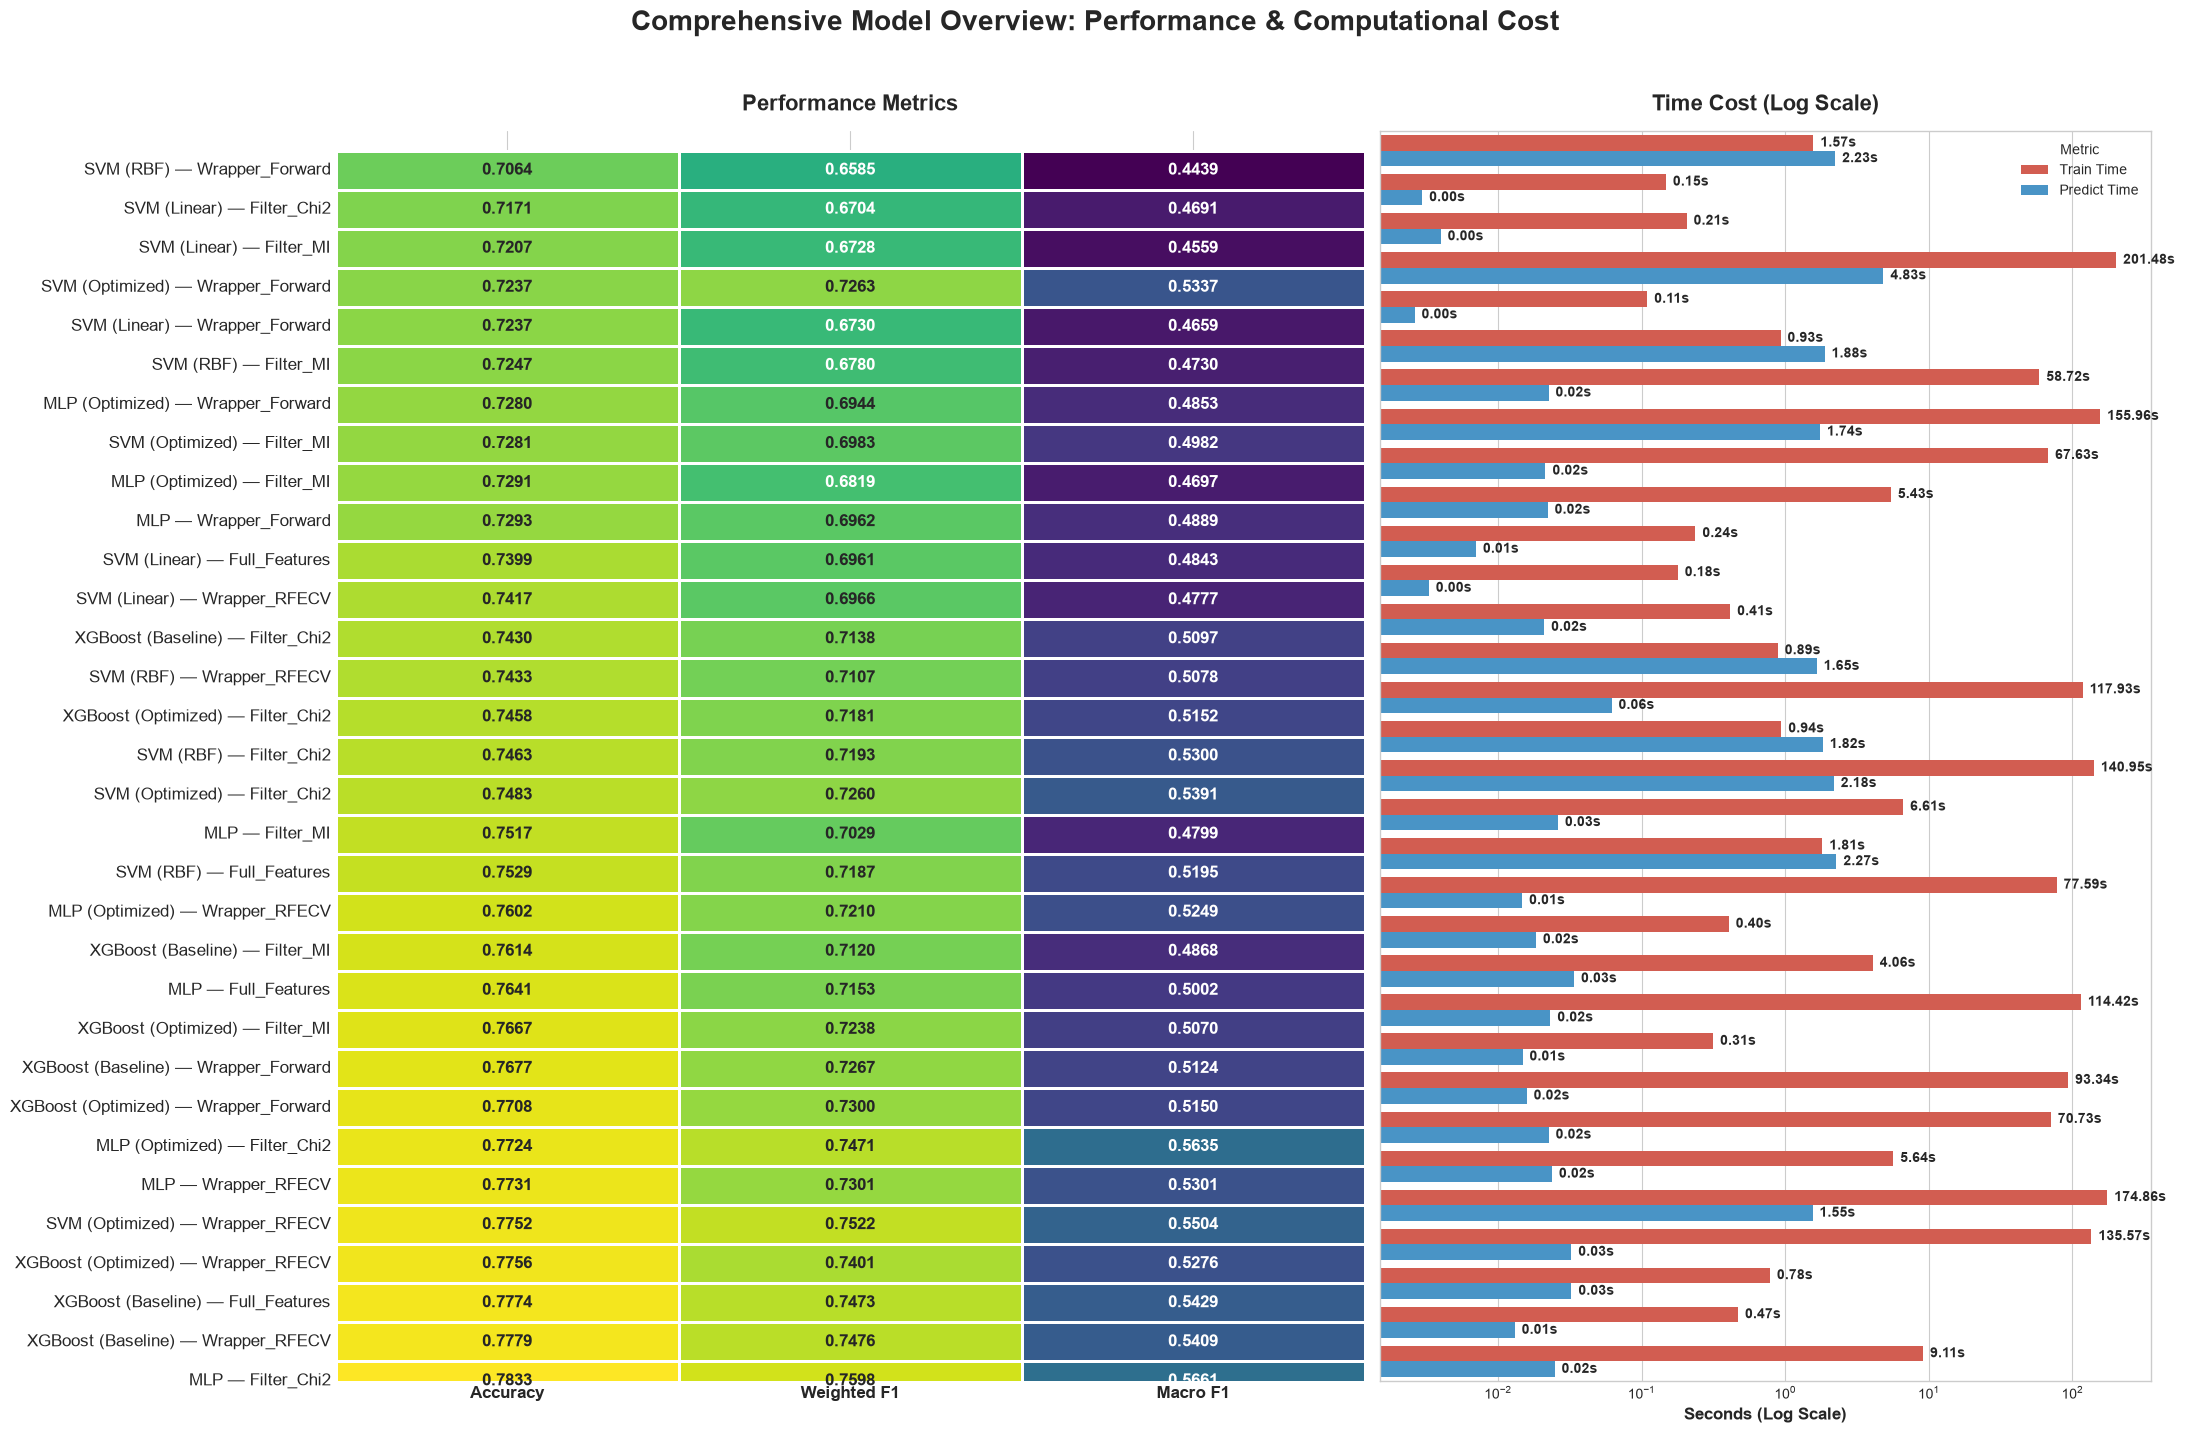

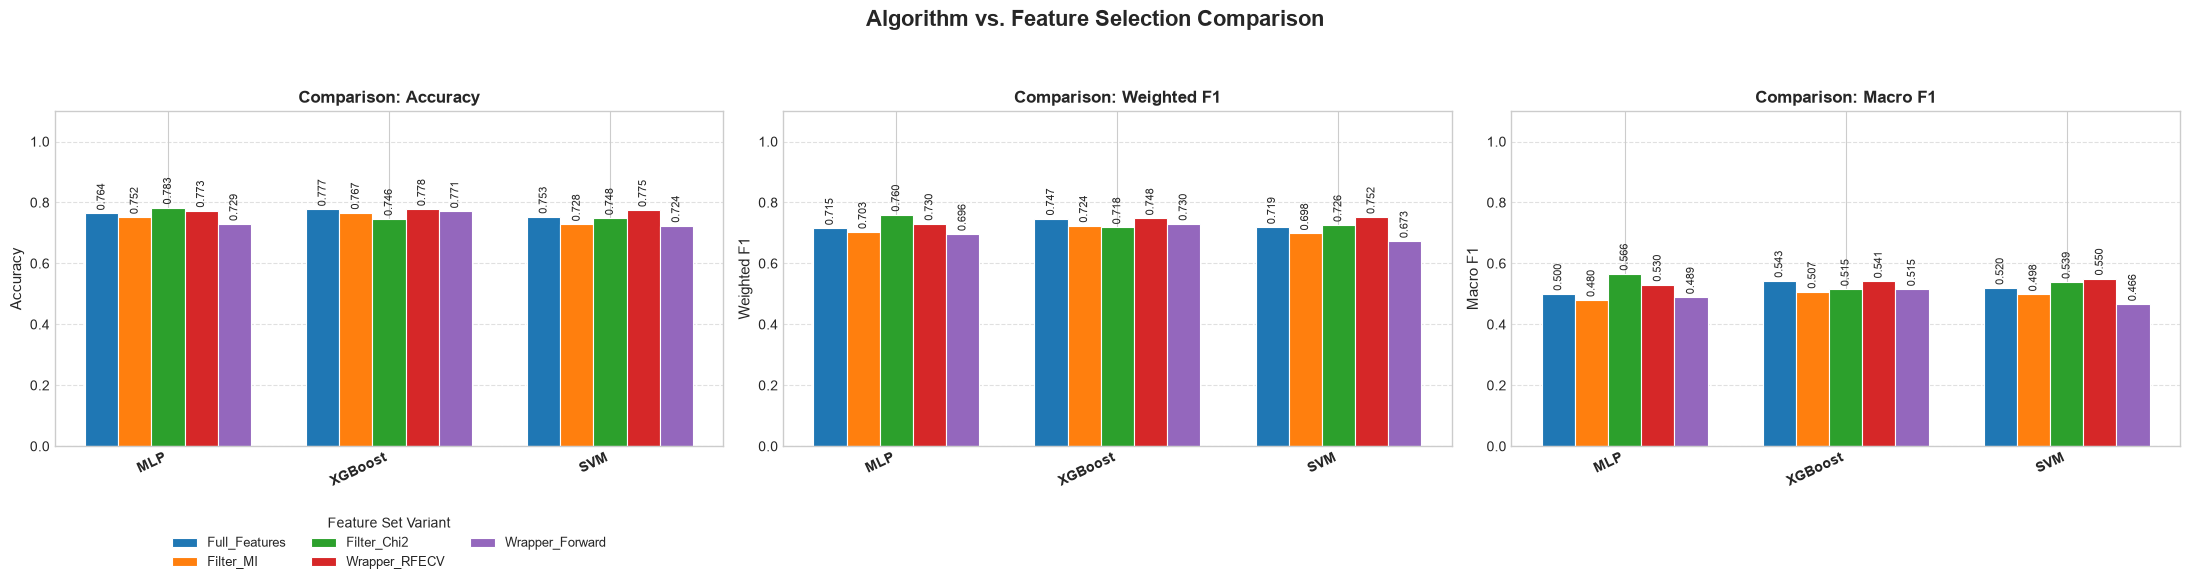



 Filter Impact vs. Full-Features Baseline (Positive = Improvement) 

Model Family     Feature Set Δ Accuracy Δ Macro F1 Train Time Predict Time
         MLP       Filter_MI    -0.0124    -0.0202      6.61s      0.0261s
         MLP     Filter_Chi2    +0.0192    +0.0659      9.11s      0.0247s
         MLP   Wrapper_RFECV    +0.0090    +0.0299      5.64s      0.0237s
         MLP Wrapper_Forward    -0.0348    -0.0113      5.43s      0.0221s
     XGBoost       Filter_MI    -0.0107    -0.0358    114.42s      0.0231s
     XGBoost     Filter_Chi2    -0.0316    -0.0277    117.93s      0.0616s
     XGBoost   Wrapper_RFECV    +0.0005    -0.0020      0.47s      0.0130s
     XGBoost Wrapper_Forward    -0.0067    -0.0279     93.34s      0.0158s
         SVM       Filter_MI    -0.0248    -0.0213    155.96s      1.7421s
         SVM     Filter_Chi2    -0.0047    +0.0195    140.95s      2.1755s
         SVM   Wrapper_RFECV    +0.0223    +0.0309    174.86s      1.5470s
         SVM Wrapper_Forward 

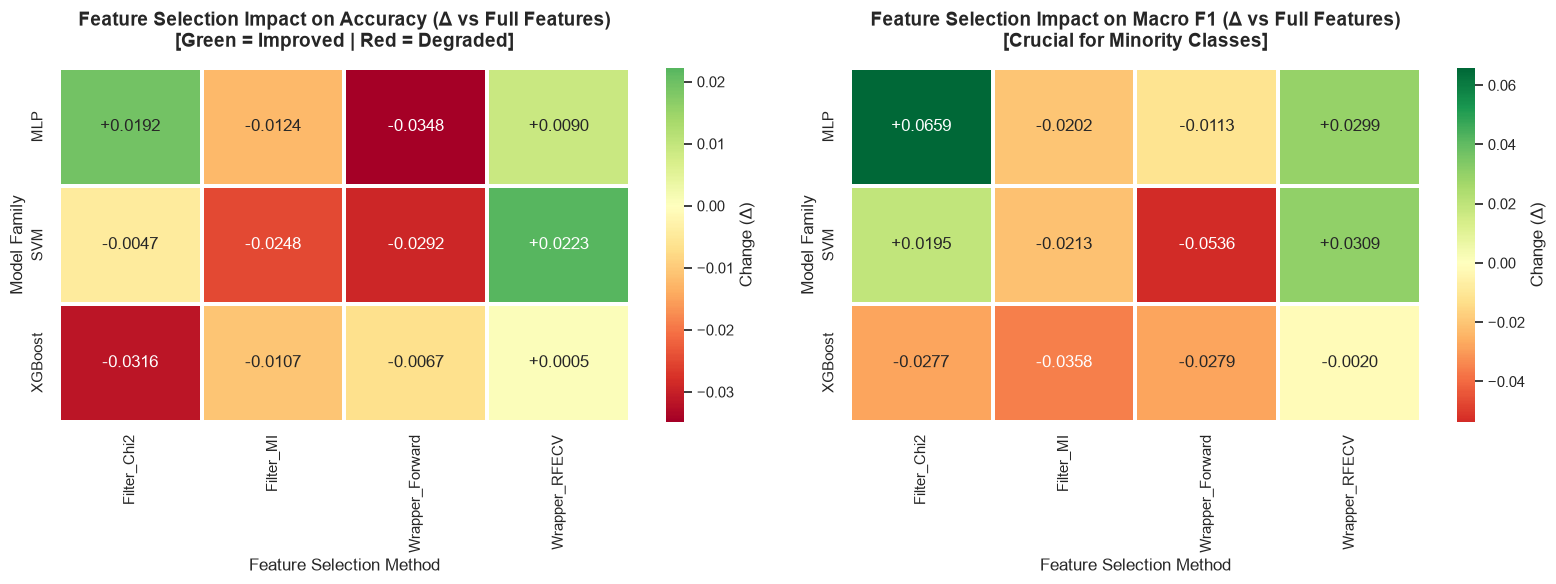

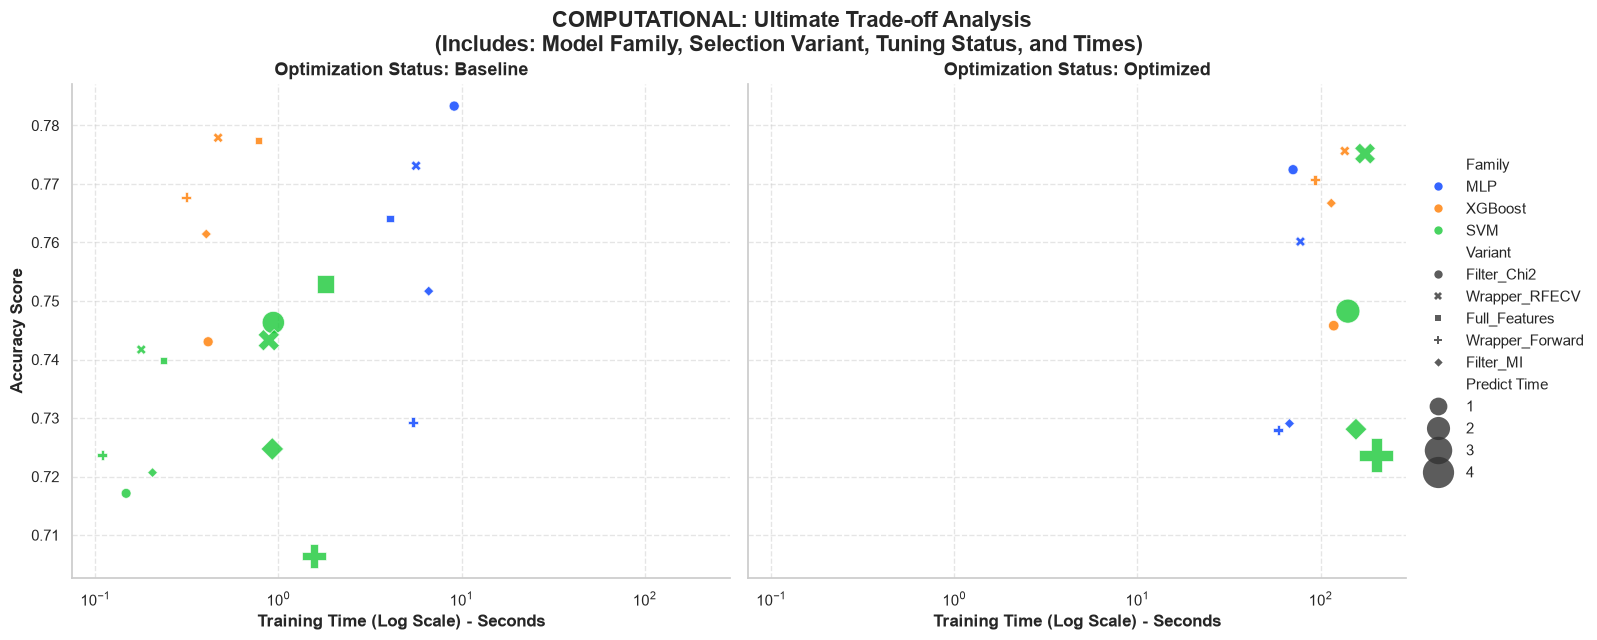

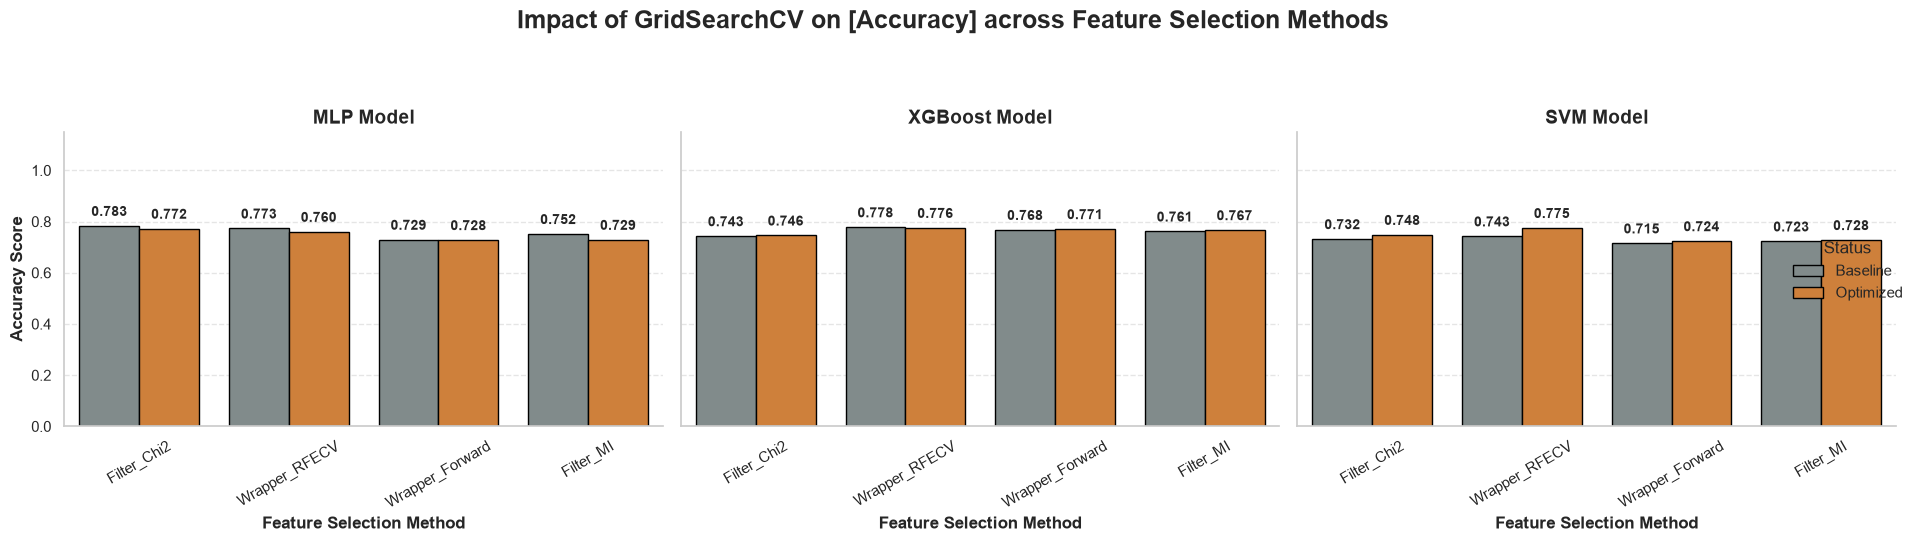

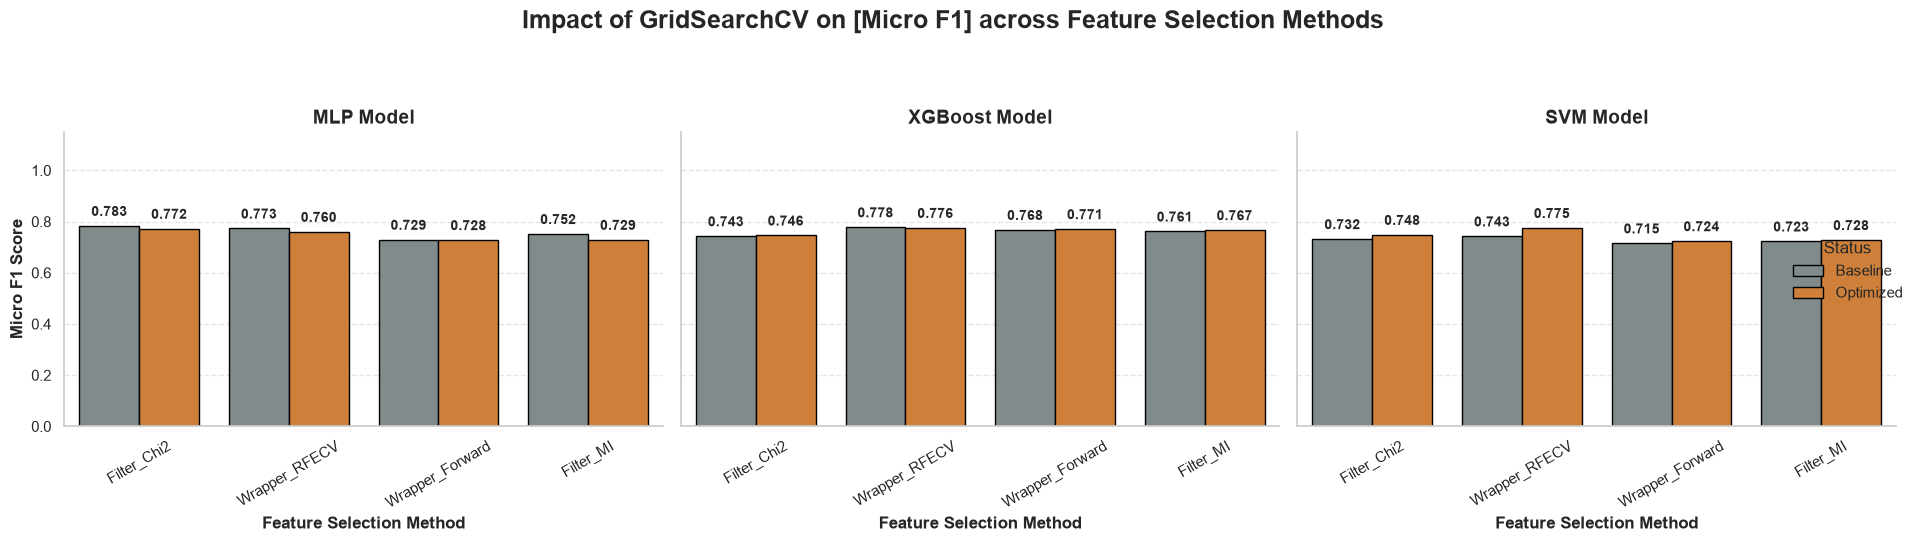

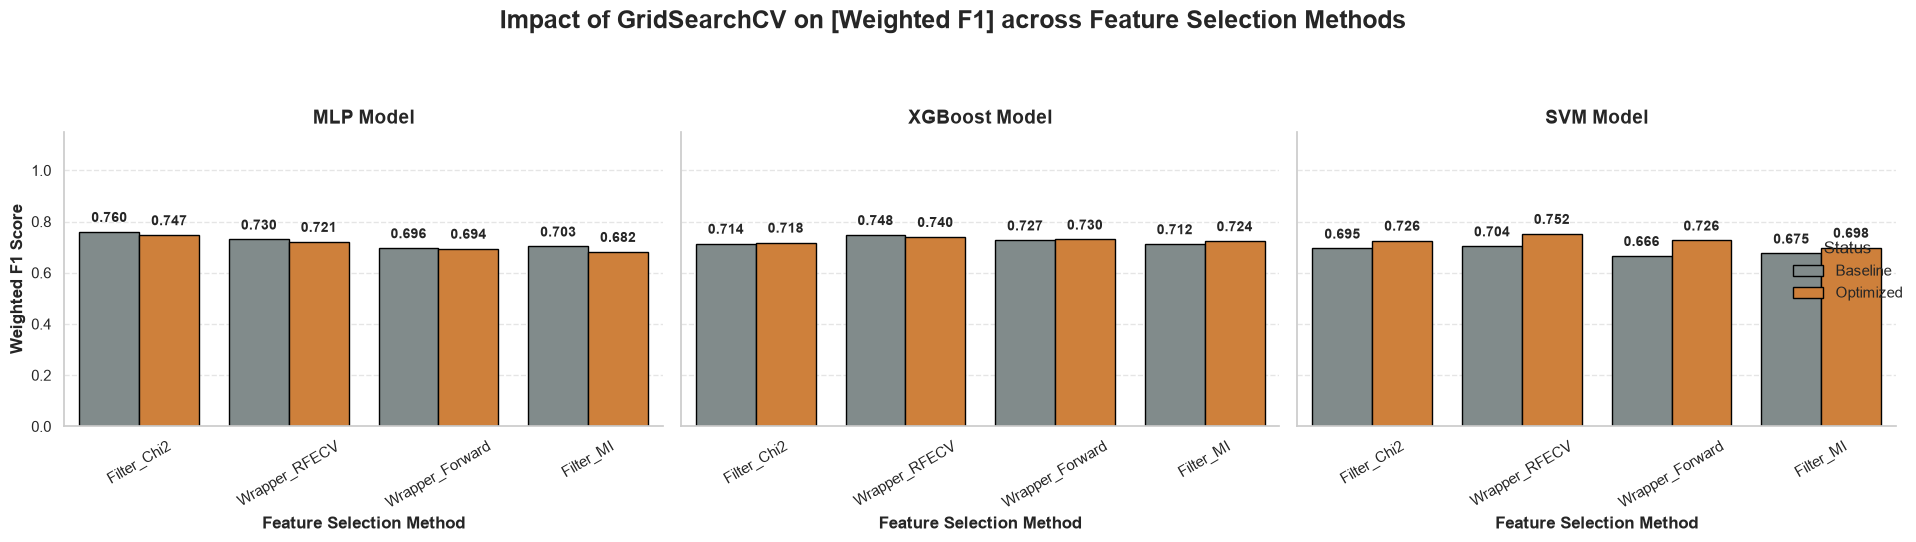

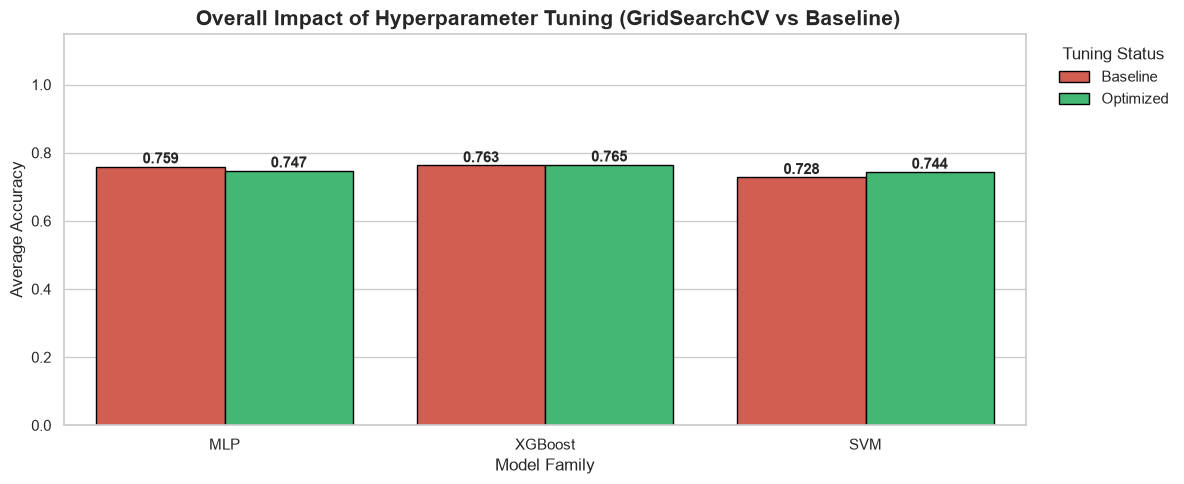

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import warnings
import io
from docx import Document
from docx.shared import Inches

warnings.filterwarnings('ignore')


doc = Document()
doc.add_heading('Machine Learning Models Evaluation Results', 0)

def add_df_to_word(df, title, doc):
    doc.add_heading(title, level=2)
    table = doc.add_table(rows=1, cols=len(df.columns))
    table.style = 'Table Grid'
    for j, col in enumerate(df.columns):
        table.cell(0, j).text = str(col)
    for row in df.itertuples(index=False):
        row_cells = table.add_row().cells
        for j, value in enumerate(row):
            row_cells[j].text = str(value)
    doc.add_paragraph('\n')

def add_plot_to_word(title, doc, plt_obj):
    doc.add_heading(title, level=2)
    memfile = io.BytesIO()
    plt_obj.savefig(memfile, format='png', bbox_inches='tight', dpi=300)
    memfile.seek(0)
    doc.add_picture(memfile, width=Inches(6.0))
    memfile.close()
    doc.add_paragraph('\n')
# ----------------------------------------

def _safe_float(v):
    try:
        val = float(v)
        return val if not np.isnan(val) else float('nan')
    except (TypeError, ValueError):
        return float('nan')

_rows = []
for name, metrics in RESULTS.items():
    train_time = (metrics.get('Train Time (s)') or 
                  metrics.get('Train Time') or 
                  metrics.get('Time') or 0)
                  
    pred_time = (metrics.get('Predict Time (s)') or 
                 metrics.get('Predict Time') or 0)
        
    _rows.append({
        'Algorithm'   : name,
        'Accuracy'    : _safe_float(metrics.get('Accuracy')),
        'Weighted F1' : _safe_float(metrics.get('Weighted F1', metrics.get('F1'))),
        'Macro F1'    : _safe_float(metrics.get('Macro F1')),
        'Train Time'  : _safe_float(train_time),
        'Predict Time': _safe_float(pred_time)
    })

results_df = pd.DataFrame(_rows).sort_values('Accuracy', ascending=False).reset_index(drop=True)

def _parse(name):
    clean_name = str(name).replace('===', '').replace('', '').strip()
    
    variant = 'Full_Features'
    for v in ['Filter_MI', 'Filter_Chi2', 'Wrapper_RFECV', 'Wrapper_Forward']:
        if v.lower() in clean_name.lower():
            variant = v
            break
            
    if variant == 'Full_Features':
        status = 'Baseline'
    else:
        
        status = 'Optimized' if 'Optimized' in clean_name else 'Baseline'
    
    if 'SVM' in clean_name: family = 'SVM'
    elif 'MLP' in clean_name: family = 'MLP'
    elif 'XGBoost' in clean_name: family = 'XGBoost'
    else: family = clean_name.split('—')[0].split('-')[0].strip()
        
    return family, status, variant

parsed_data = results_df['Algorithm'].apply(lambda n: pd.Series(_parse(n)))
results_df['Family'] = parsed_data[0]
results_df['Status'] = parsed_data[1]
results_df['Variant'] = parsed_data[2]

results_df = results_df[~((results_df['Variant'] == 'Full_Features') & 
                          (results_df['Algorithm'].str.contains('Optimized', case=False, na=False)))].reset_index(drop=True)

pretty = results_df.copy()
for col in ['Accuracy', 'Weighted F1', 'Macro F1']:
    pretty[col] = pretty[col].map(lambda x: f'{x:.4f}' if not pd.isna(x) else 'N/A')
for col in ['Train Time', 'Predict Time']:
    pretty[col] = pretty[col].map(lambda x: f'{x:.2f}s' if not pd.isna(x) and x > 0 else 'N/A')

print(''*95)

print(''*95)
print(pretty[['Algorithm', 'Accuracy', 'Weighted F1', 'Macro F1', 'Train Time', 'Predict Time']].to_string(index=False))
print('\n')


add_df_to_word(pretty[['Algorithm', 'Accuracy', 'Weighted F1', 'Macro F1', 'Train Time', 'Predict Time']], 
               'Final Results Summary (Sorted by Accuracy)', doc)

clean_df = results_df.dropna(subset=['Accuracy']).copy()
df_comprehensive = clean_df.sort_values('Accuracy', ascending=True).copy()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(22, 14), gridspec_kw={'width_ratios': [2, 1.5]}, sharey=True)

metrics_cols = ['Accuracy', 'Weighted F1', 'Macro F1']
metrics_df = df_comprehensive.set_index('Algorithm')[metrics_cols]

sns.heatmap(metrics_df, annot=True, fmt=".4f", cmap="viridis", cbar=False, 
            linewidths=1, linecolor='white', ax=ax1, annot_kws={"size": 12, "weight": "bold"})

ax1.set_title('Performance Metrics', fontsize=16, fontweight='bold', pad=15)
ax1.set_ylabel('')
ax1.tick_params(axis='y', labelsize=12, labelrotation=0)
ax1.tick_params(axis='x', labelsize=12)
plt.setp(ax1.get_xticklabels(), fontweight='bold')

time_df = df_comprehensive[['Algorithm', 'Train Time', 'Predict Time']].melt(id_vars='Algorithm', var_name='Metric', value_name='Time(s)')

sns.barplot(data=time_df, y='Algorithm', x='Time(s)', hue='Metric', ax=ax2, palette=['#e74c3c', '#3498db'])

ax2.set_xscale('log')
ax2.set_title('Time Cost (Log Scale)', fontsize=16, fontweight='bold', pad=15)
ax2.set_ylabel('')
ax2.set_xlabel('Seconds (Log Scale)', fontsize=12, fontweight='bold')
ax2.tick_params(axis='y', left=False)

for p in ax2.patches:
    width = p.get_width()
    if width > 0 and not np.isnan(width):
        ax2.annotate(f"{width:.2f}s", 
                     (width, p.get_y() + p.get_height() / 2.),
                     ha='left', va='center', fontsize=10, fontweight='bold',
                     xytext=(5, 0), textcoords='offset points')

plt.suptitle('Comprehensive Model Overview: Performance & Computational Cost', fontsize=20, fontweight='bold', y=1.02)
plt.tight_layout()

# إضافة رسمة الـ Comprehensive للوورد
add_plot_to_word('Comprehensive Model Overview', doc, plt)
plt.show()

families = results_df['Family'].drop_duplicates().tolist()
variants = ['Full_Features', 'Filter_MI', 'Filter_Chi2', 'Wrapper_RFECV', 'Wrapper_Forward']
existing_variants = [v for v in variants if v in results_df['Variant'].values]

colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']
variant_colors = dict(zip(existing_variants, colors[:len(existing_variants)]))

fig, axes = plt.subplots(1, 3, figsize=(22, 6))
metrics_to_plot = ['Accuracy', 'Weighted F1', 'Macro F1']

for ax, metric in zip(axes, metrics_to_plot):
    x = np.arange(len(families))
    width = 0.15  
    
    for j, v in enumerate(existing_variants):
        vals = []
        for fam in families:
            sub = results_df[(results_df['Family'] == fam) & (results_df['Variant'] == v)]
            vals.append(sub[metric].iloc[0] if len(sub) else float('nan'))
        
        offset = (j - len(existing_variants)/2 + 0.5) * width
        bars = ax.bar(x + offset, vals, width, label=v, color=variant_colors.get(v, '#333'), edgecolor='white', linewidth=0.8)
        
        for bar, val in zip(bars, vals):
            if not np.isnan(val):
                ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
                        f'{val:.3f}', ha='center', va='bottom', fontsize=8, rotation=90)
    
    ax.set_xticks(x)
    ax.set_xticklabels(families, rotation=25, ha='right', fontsize=10, fontweight='bold')
    ax.set_ylim(0, 1.1)
    ax.set_title(f'Comparison: {metric}', fontsize=12, fontweight='bold')
    ax.set_ylabel(metric, fontsize=11)
    ax.grid(axis='y', linestyle='--', alpha=0.6)
    
    if metric == 'Accuracy':
        ax.legend(title='Feature Set Variant', fontsize=9, loc='lower center', bbox_to_anchor=(0.5, -0.4), ncol=3)

plt.suptitle('Algorithm vs. Feature Selection Comparison', fontsize=16, fontweight='bold', y=1.05)
plt.tight_layout()


add_plot_to_word('Algorithm vs. Feature Selection Comparison', doc, plt)
plt.show()

delta_rows = []
for fam in families:
    base = results_df[(results_df['Family'] == fam) & (results_df['Variant'] == 'Full_Features') & (results_df['Status'] == 'Baseline')]
    if not len(base):
        base = results_df[(results_df['Family'] == fam) & (results_df['Variant'] == 'Full_Features')]
    if not len(base): continue
    
    base_acc = base['Accuracy'].iloc[0]
    base_mac = base['Macro F1'].iloc[0]
    
    for v in existing_variants:
        if v == 'Full_Features': continue
        sub = results_df[(results_df['Family'] == fam) & (results_df['Variant'] == v)]
        if not len(sub): continue
        
        delta_rows.append({
            'Model Family': fam,
            'Feature Set': v,
            'Δ Accuracy': sub['Accuracy'].iloc[0] - base_acc,
            'Δ Macro F1': sub['Macro F1'].iloc[0] - base_mac,
            'Train Time': sub['Train Time'].iloc[0],      
            'Predict Time': sub['Predict Time'].iloc[0]   
        })

delta_df = pd.DataFrame(delta_rows)
print('\n' + ''*85)
print(' Filter Impact vs. Full-Features Baseline (Positive = Improvement) ')
print(''*85)
if not delta_df.empty:
    print(delta_df.to_string(index=False, formatters={
        'Δ Accuracy': '{:+.4f}'.format, 
        'Δ Macro F1': '{:+.4f}'.format,
        'Train Time': '{:.2f}s'.format,
        'Predict Time': '{:.4f}s'.format
    }))
    
 
    formatted_delta_df = delta_df.copy()
    formatted_delta_df['Δ Accuracy'] = formatted_delta_df['Δ Accuracy'].map('{:+.4f}'.format)
    formatted_delta_df['Δ Macro F1'] = formatted_delta_df['Δ Macro F1'].map('{:+.4f}'.format)
    formatted_delta_df['Train Time'] = formatted_delta_df['Train Time'].map('{:.2f}s'.format)
    formatted_delta_df['Predict Time'] = formatted_delta_df['Predict Time'].map('{:.4f}s'.format)
    add_df_to_word(formatted_delta_df, 'Filter Impact vs. Full-Features Baseline', doc)

    print("\n" + ""*40)
    print(""*40 + "\n")
    
    sns.set_theme(style="darkgrid", palette="deep")
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    pivot_acc_delta = delta_df.pivot(index='Model Family', columns='Feature Set', values='Δ Accuracy')
    pivot_mac_delta = delta_df.pivot(index='Model Family', columns='Feature Set', values='Δ Macro F1')
    
    sns.heatmap(pivot_acc_delta, annot=True, cmap='RdYlGn', center=0, fmt='+.4f', 
                linewidths=1.5, linecolor='white', cbar_kws={'label': 'Change (Δ)'}, ax=axes[0])
    axes[0].set_title('Feature Selection Impact on Accuracy (Δ vs Full Features)\n[Green = Improved | Red = Degraded]', 
                      fontweight='bold', fontsize=14, pad=15)
    axes[0].set_xlabel('Feature Selection Method', fontsize=12)
    axes[0].set_ylabel('Model Family', fontsize=12)
    
    sns.heatmap(pivot_mac_delta, annot=True, cmap='RdYlGn', center=0, fmt='+.4f', 
                linewidths=1.5, linecolor='white', cbar_kws={'label': 'Change (Δ)'}, ax=axes[1])
    axes[1].set_title('Feature Selection Impact on Macro F1 (Δ vs Full Features)\n[Crucial for Minority Classes]', 
                      fontweight='bold', fontsize=14, pad=15)
    axes[1].set_xlabel('Feature Selection Method', fontsize=12)
    axes[1].set_ylabel('Model Family', fontsize=12)
    
    plt.tight_layout()
    
    add_plot_to_word('Feature Selection Impact Heatmaps', doc, plt)
    plt.show()

sns.set_theme(style="whitegrid")
clean_df = results_df.dropna(subset=['Accuracy']).copy()

def get_micro_f1(algo_name):
    return RESULTS.get(algo_name, {}).get('Micro F1', RESULTS.get(algo_name, {}).get('Accuracy', np.nan))
clean_df['Micro F1'] = clean_df['Algorithm'].apply(get_micro_f1)

def categorize_fs(variant):
    if 'Filter' in variant: return 'Filter Methods'
    elif 'Wrapper' in variant: return 'Wrapper Methods'
    return 'Full Features'
clean_df['FS_Type'] = clean_df['Variant'].apply(categorize_fs)

print("\n" + ""*40)
print(""*40 + "\n")

g = sns.relplot(
    data=clean_df,
    x='Train Time',
    y='Accuracy',
    col='Status',        
    hue='Family',        
    style='Variant',     
    size='Predict Time', 
    sizes=(50, 600),     
    alpha=0.8,
    palette='bright',
    height=6,
    aspect=1.2,
    kind='scatter'
)

g.fig.suptitle(' COMPUTATIONAL: Ultimate Trade-off Analysis\n(Includes: Model Family, Selection Variant, Tuning Status, and Times)', 
               fontweight='bold', fontsize=16, y=1.06)
g.set_axis_labels('Training Time (Log Scale) - Seconds', 'Accuracy Score', fontweight='bold')
g.set_titles("Optimization Status: {col_name}", fontweight='bold', size=13)

for ax in g.axes.flat:
    ax.set_xscale('log')
    ax.grid(True, linestyle='--', alpha=0.5)


add_plot_to_word('Computational vs Accuracy Trade-off Analysis', doc, plt)
plt.show()

selection_only_df = clean_df[clean_df['Variant'] != 'Full_Features'].copy()

print("\n" + ""*50)
print(""*50 + "\n")

target_metrics = ['Accuracy', 'Micro F1', 'Weighted F1']
status_colors = {'Baseline': '#7f8c8d', 'Optimized': '#e67e22'}

for metric in target_metrics:
    g = sns.catplot(
        data=selection_only_df, 
        x='Variant',          
        y=metric,             
        hue='Status',         
        col='Family',         
        kind='bar', 
        palette=status_colors,
        height=5, 
        aspect=1.2,
        edgecolor='black',
        ci=None
    )
    
    g.fig.suptitle(f'Impact of GridSearchCV on [{metric}] across Feature Selection Methods', 
                   fontsize=18, fontweight='bold', y=1.08)
    g.set_axis_labels("Feature Selection Method", f"{metric} Score", fontsize=12, fontweight='bold')
    g.set_titles("{col_name} Model", size=14, fontweight='bold')
    
    for ax in g.axes.flat:
        ax.set_ylim(0, 1.15) 
        ax.tick_params(axis='x', rotation=30) 
        ax.grid(axis='y', linestyle='--', alpha=0.5)
        
        for p in ax.patches:
            height = p.get_height()
            if height > 0 and not np.isnan(height):
                ax.annotate(f"{height:.3f}", 
                            (p.get_x() + p.get_width() / 2., height),
                            ha='center', va='bottom', fontsize=10, rotation=0, 
                            xytext=(0, 5), textcoords='offset points', fontweight='bold')

    plt.tight_layout()
   
    add_plot_to_word(f'GridSearchCV Impact on {metric}', doc, plt)
    plt.show()

print("\n" + ""*40)
print(""*40 + "\n")

opt_vs_base = clean_df[clean_df['Variant'] != 'Full_Features'].copy()

if not opt_vs_base.empty:
    plt.figure(figsize=(12, 5))
    sns.barplot(data=opt_vs_base, x='Family', y='Accuracy', hue='Status', ci=None, palette=['#e74c3c', '#2ecc71'], edgecolor='black')
    plt.title(' Overall Impact of Hyperparameter Tuning (GridSearchCV vs Baseline)', fontweight='bold', fontsize=15)
    plt.ylabel('Average Accuracy', fontsize=12)
    plt.xlabel('Model Family', fontsize=12)
    plt.ylim(0, 1.15)
    
    ax = plt.gca()
    for p in ax.patches:
        height = p.get_height()
        if height > 0 and not np.isnan(height):
            ax.annotate(f"{height:.3f}", (p.get_x() + p.get_width() / 2., height),
                        ha='center', va='bottom', fontsize=11, fontweight='bold')
            
    plt.legend(title='Tuning Status', bbox_to_anchor=(1.02, 1), loc=2)
    plt.tight_layout()
   
    add_plot_to_word('Overall Impact of Hyperparameter Tuning', doc, plt)
    plt.show()


doc.save('Documentationnslqq.docx')


In [21]:
results_df['Dataset'] = 'NSL-KDD'
results_df.to_csv('NSL_KDD_Resultsqq.csv', index=False)


In [19]:
!pip install python-docx

   ---------------------------------------- 0.0/4.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/4.1 MB ? eta -:--:--
   -- ------------------------------------- 0.3/4.1 MB ? eta -:--:--
   -- ------------------------------------- 0.3/4.1 MB ? eta -:--:--
   ----- ---------------------------------- 0.5/4.1 MB 1.0 MB/s eta 0:00:04
   ------- -------------------------------- 0.8/4.1 MB 1.1 MB/s eta 0:00:04
   ---------- ----------------------------- 1.0/4.1 MB 1.1 MB/s eta 0:00:03
   ------------ --------------------------- 1.3/4.1 MB 1.2 MB/s eta 0:00:03
   ------------------ --------------------- 1.8/4.1 MB 1.2 MB/s eta 0:00:02
   -------------------- ------------------- 2.1/4.1 MB 1.3 MB/s eta 0:00:02
   ----------------------- ---------------- 2.4/4.1 MB 1.3 MB/s eta 0:00:02
   ---------------------------- ----------- 2.9/4.1 MB 1.4 MB/s eta 0:00:01
   ------------------------------ --------- 3.1/4.1 MB 1.4 MB/s eta 0:00:01
   --------------------------------- ---